In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
base = "/content/drive/MyDrive/dreem-automated-sleep-staging"
print(os.listdir(base))


Mounted at /content/drive
['sample.csv', 'targets_train.csv', 'sample', 'test_records', 'training_records']


In [ ]:
import pandas as pd, numpy as np

# Load the metadata files
targets = pd.read_csv(os.path.join(base, "targets_train.csv"))
sample = pd.read_csv(os.path.join(base, "sample.csv"))

print("targets_train.csv shape:", targets.shape)
print(targets.head(915))

# Peek inside one .npy record
train_path = os.path.join(base, "training_records")
example_file = os.path.join(train_path, "record_0.npy")
example = np.load(example_file, allow_pickle=True)

print(type(example))
print("Shape:", getattr(example, 'shape', 'No shape'))


targets_train.csv shape: (6175, 4)
     record  index  identifier  target
0         0      0           0       0
1         0      1           1       0
2         0      2           2       0
3         0      3           3       0
4         0      4           4       0
..      ...    ...         ...     ...
910       0    910         910       0
911       0    911         911       0
912       0    912         912       0
913       1      0       10000       0
914       1      1       10001       0

[915 rows x 4 columns]
<class 'numpy.ndarray'>
Shape: (913, 42001)


In [ ]:
# 1. Number of participants
num_participants = targets['record'].nunique()

# 2. Days per participant (1 record ≈ 1 day)
days_per_participant = targets.groupby('record')['index'].max() + 1

# 3. Total labels
total_labels = len(targets)

# 4. Label distribution
label_counts = targets['target'].value_counts().to_dict()

# 5. Check input streams for one record
record_data = np.load(example_file, allow_pickle=True)
shape_info = getattr(record_data, 'shape', None)

print("Participants:", num_participants)
print("Days per participant:", days_per_participant.describe())
print("Total labels:", total_labels)
print("Label distribution:", label_counts)
print("Example record shape:", shape_info)


Participants: 7
Days per participant: count       7.000000
mean      882.142857
std        78.946033
min       806.000000
25%       822.500000
50%       861.000000
75%       917.500000
max      1028.000000
Name: index, dtype: float64
Total labels: 6175
Label distribution: {2: 2317, 4: 1850, 3: 1375, 0: 389, 1: 244}
Example record shape: (913, 42001)


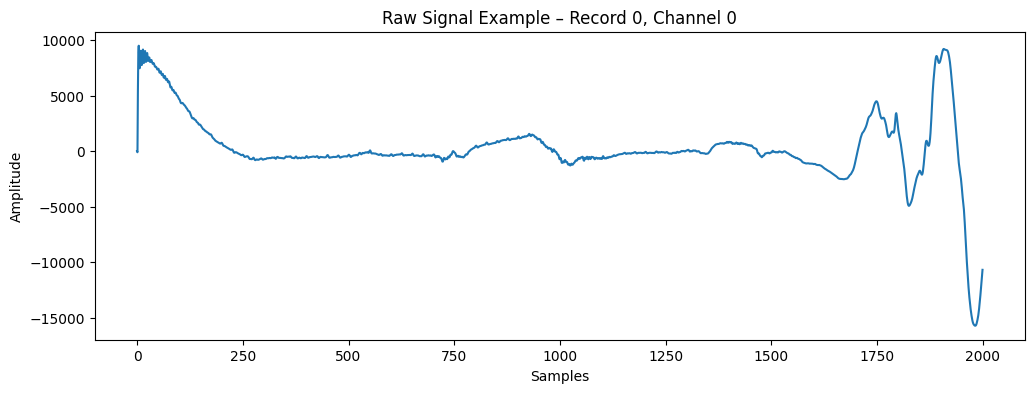

In [ ]:
import matplotlib.pyplot as plt

# If array shape = (channels, samples)
plt.figure(figsize=(12,4))
plt.plot(example[0][:2000])
plt.title("Raw Signal Example – Record 0, Channel 0")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


In [ ]:
##########TASK 2 ##########

In [ ]:
# Filter targets for record_0
record_id = 0
record_targets = targets[targets['record'] == record_id].reset_index(drop=True)

# View how many times each sleep stage appears in this record
print("Sleep stage counts in record_0:")
print(record_targets['target'].value_counts())

Sleep stage counts in record_0:
target
2    370
4    282
3    148
0     71
1     42
Name: count, dtype: int64


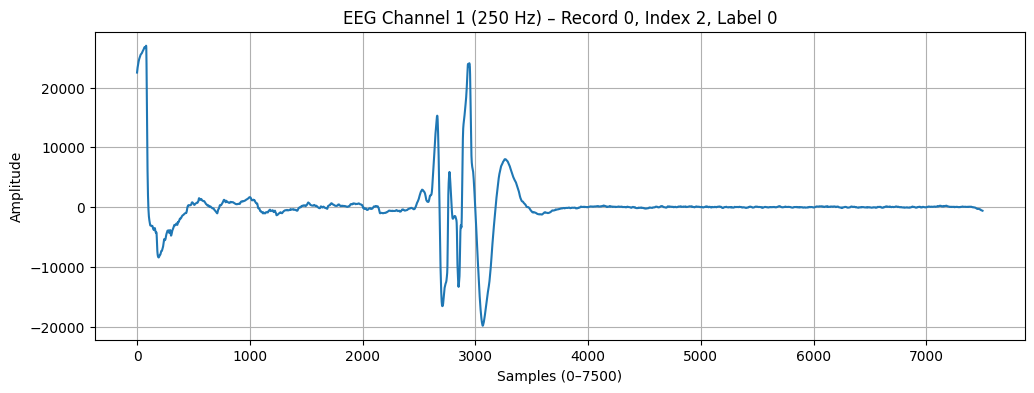

In [ ]:
#plotting the first EEG channel (columns 1:7501); For record_0, and index 2 (i.e., the 3rd 30-second segment); EEG is sampled at 250 Hz, so this is a 30-second signal; 250 Hz × 30 s = 7500 samples

row = 2  # index = 2
signal_row = example[row]

# EEG channel 1 is in columns 1 to 7501
eeg1 = signal_row[1:7501]

plt.figure(figsize=(12, 4))
plt.plot(eeg1)
label = targets[(targets['record'] == 0) & (targets['index'] == 2)]['target'].values[0]
plt.title(f"EEG Channel 1 (250 Hz) – Record 0, Index 2, Label {label}")
plt.xlabel("Samples (0–7500)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [ ]:
#to confirm the correct data is plotted
targets[(targets['record'] == 0) & (targets['index'] == 2)]

,record,index,identifier,target
2,0,2,2,0


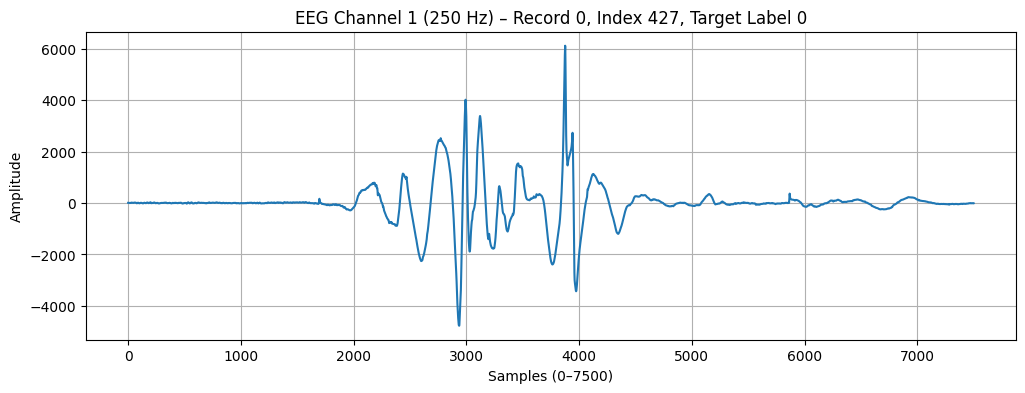

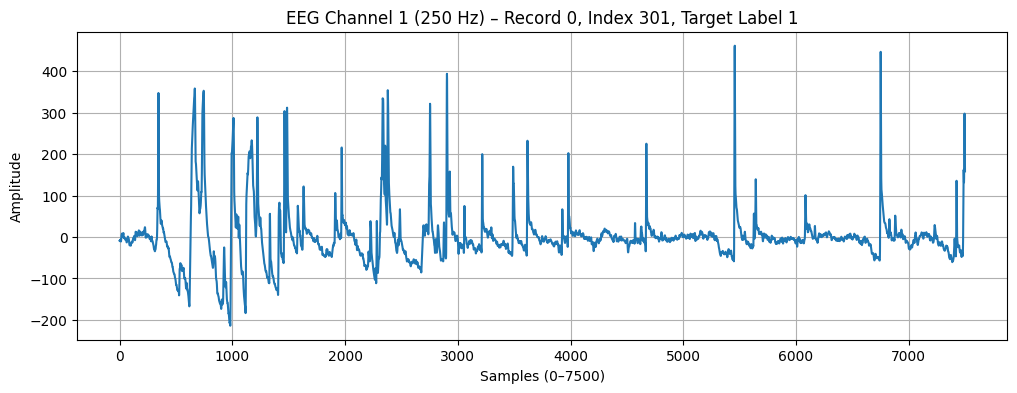

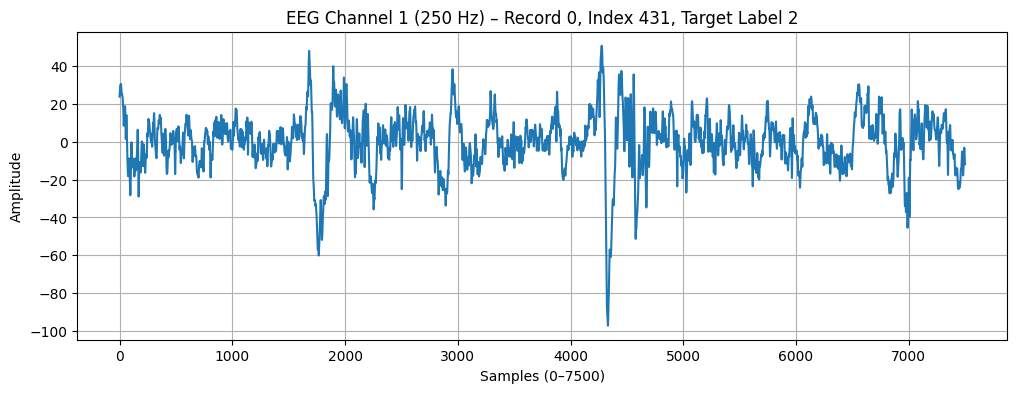

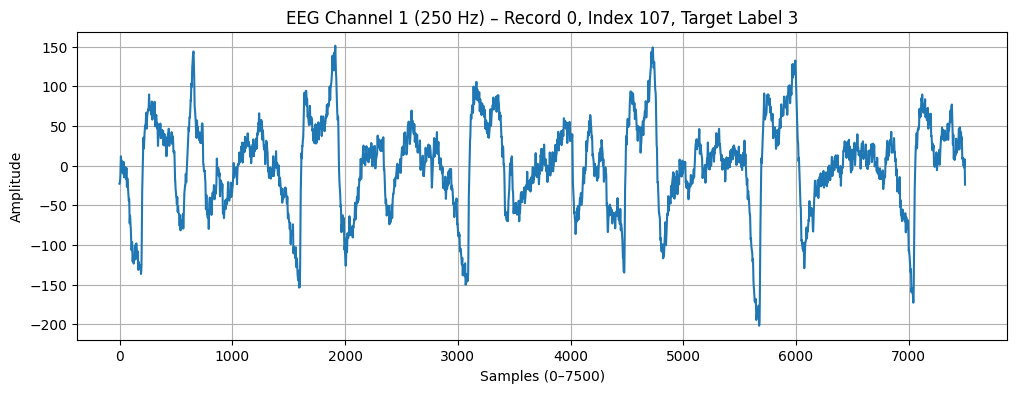

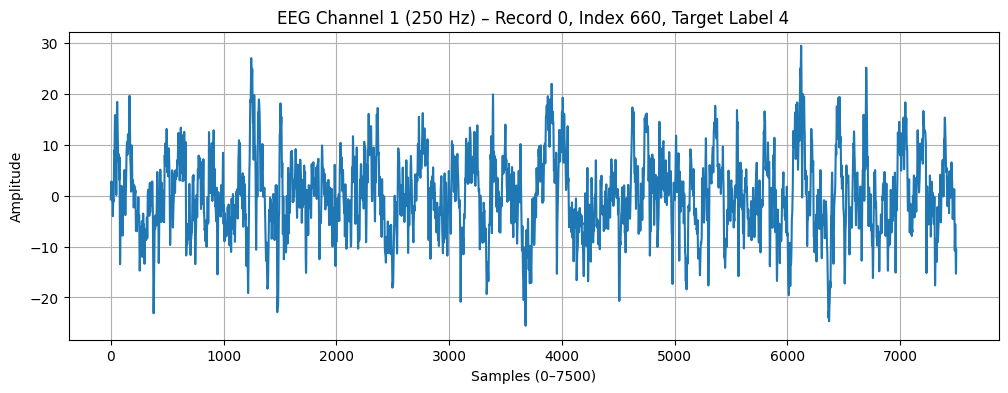

In [ ]:
import matplotlib.pyplot as plt

# Get all targets for record 0
record_targets = targets[targets['record'] == 0]

# Loop through each sleep stage label (0 to 4)
for label in sorted(record_targets['target'].unique()):
    # Find all indices with that label
    label_rows = record_targets[record_targets['target'] == label]

    # Skip if label not present
    if label_rows.empty:
        print(f"Label {label} not found in record 0")
        continue

    # Pick the middle index for better representation
    row_index = label_rows.iloc[len(label_rows) // 2]['index']

    # Extract the signal row
    signal_row = example[int(row_index)]  # convert index to int just in case
    eeg1 = signal_row[1:7501]

    # Plot
    plt.figure(figsize=(12, 4))
    plt.plot(eeg1)
    plt.title(f"EEG Channel 1 (250 Hz) – Record 0, Index {row_index}, Target Label {label}")
    plt.xlabel("Samples (0–7500)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

In [ ]:
print(targets[targets['record'] == 0].head(10))

   record  index  identifier  target
0       0      0           0       0
1       0      1           1       0
2       0      2           2       0
3       0      3           3       0
4       0      4           4       0
5       0      5           5       0
6       0      6           6       0
7       0      7           7       1
8       0      8           8       1
9       0      9           9       1


In [ ]:
############ TASK 3 ##########

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample, butter, filtfilt

In [ ]:
#elect 1 EEG Signal Segment (from record_0)
# Choose a specific epoch (e.g., index 100)
row_index = 100
signal_row = example[row_index]

# Extract EEG Channel 1: columns 1–7501 (30 seconds at 250 Hz)
eeg_raw = signal_row[1:7501]
original_fs = 250  # original sampling rate (Hz)
target_fs = 128    # target sampling rate (Hz)

In [ ]:
# Number of samples in resampled signal
num_samples = int(len(eeg_raw) * target_fs / original_fs)

# Resample
eeg_resampled = resample(eeg_raw, num_samples)

In [ ]:
# bandpass filter: Allows only frequencies within a specific range to pass, and removes everything outside that range.
#So the filter keeps frequencies between 0.5–45 Hz, and removes the rest
def bandpass_filter(signal, fs, lowcut=0.5, highcut=45, order=4):
    nyq = 0.5 * fs  # Nyquist Frequency
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

eeg_filtered = bandpass_filter(eeg_resampled, fs=target_fs)

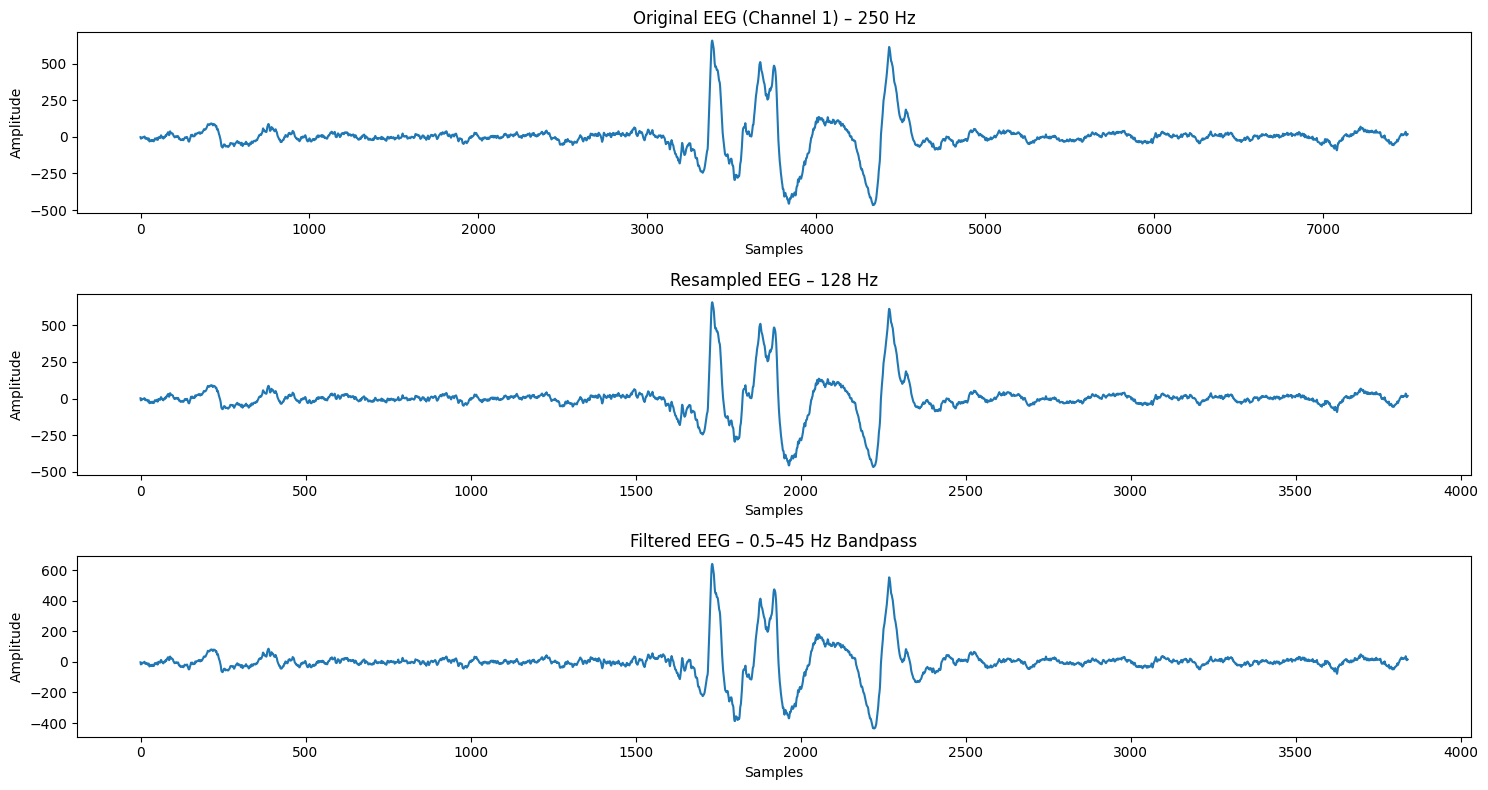

In [ ]:
plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1)
plt.plot(eeg_raw)
plt.title("Original EEG (Channel 1) – 250 Hz")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 2)
plt.plot(eeg_resampled)
plt.title("Resampled EEG – 128 Hz")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 3)
plt.plot(eeg_filtered)
plt.title("Filtered EEG – 0.5–45 Hz Bandpass")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [ ]:
#### Since the bandpass-filtered signal did not differ significantly from the resampled version, we can infer that the original EEG segment had relatively
###low noise, and did not contain substantial drift or high-frequency artifacts.

Missing values: 0
No missing values found. Signal is clean.


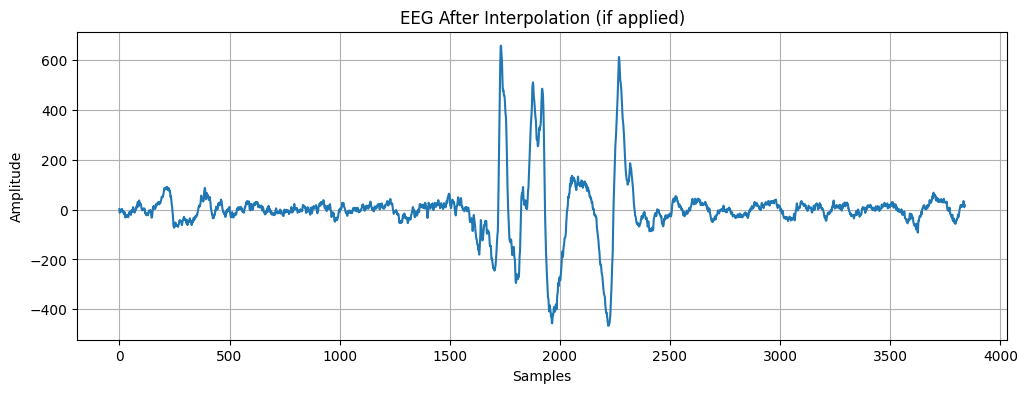

In [ ]:
# Use the resampled signal for this check
import numpy as np
import matplotlib.pyplot as plt

# Introduce a fake missing value (optional, to simulate interpolation)
# eeg_resampled[1000:1005] = np.nan  # uncomment to simulate missing values

# Check for missing values
missing_count = np.isnan(eeg_resampled).sum()
print(f"Missing values: {missing_count}")

# Interpolate if any are found
if missing_count > 0:
    from pandas import Series
    eeg_interp = Series(eeg_resampled).interpolate(method='linear').to_numpy()
    print("Interpolated missing values.")
else:
    eeg_interp = eeg_resampled  # No interpolation needed
    print("No missing values found. Signal is clean.")

# Plot
plt.figure(figsize=(12, 4))
plt.plot(eeg_interp)
plt.title("EEG After Interpolation (if applied)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [ ]:
##### For preprocessing, we selected a representative EEG epoch from record_0.npy (channel 1).
###The chosen 30-second segment was used to demonstrate resampling to 128 Hz, bandpass filtering between 0.5–45 Hz, and interpolation (if needed).
###This allowed for a clear, focused analysis of the signal preprocessing pipeline.

In [ ]:
## TASK 3 for acclerometer

In [ ]:
# Pick any row/epoch (e.g., 100)
row_index = 100
signal_row = example[row_index]

# Accel X-axis: columns 37501 to 39000 (Python slice is [37501:39001])
accel_x_raw = signal_row[37501:39001]

original_fs_accel = 50  # original accel sampling rate
target_fs = 128         # target rate (same as EEG)

In [ ]:
from scipy.signal import resample

num_samples = int(len(accel_x_raw) * target_fs / original_fs_accel)
accel_x_resampled = resample(accel_x_raw, num_samples)

In [ ]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, fs, lowcut=0.1, highcut=15, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

accel_x_filtered = bandpass_filter(accel_x_resampled, fs=target_fs)

In [ ]:
from pandas import Series
import numpy as np

missing_count = np.isnan(accel_x_filtered).sum()
print("Missing values:", missing_count)

if missing_count > 0:
    accel_x_interp = Series(accel_x_filtered).interpolate(method='linear').to_numpy()
    print("Interpolated missing values.")
else:
    accel_x_interp = accel_x_filtered
    print("No missing values found. Signal is clean.")

Missing values: 0
No missing values found. Signal is clean.


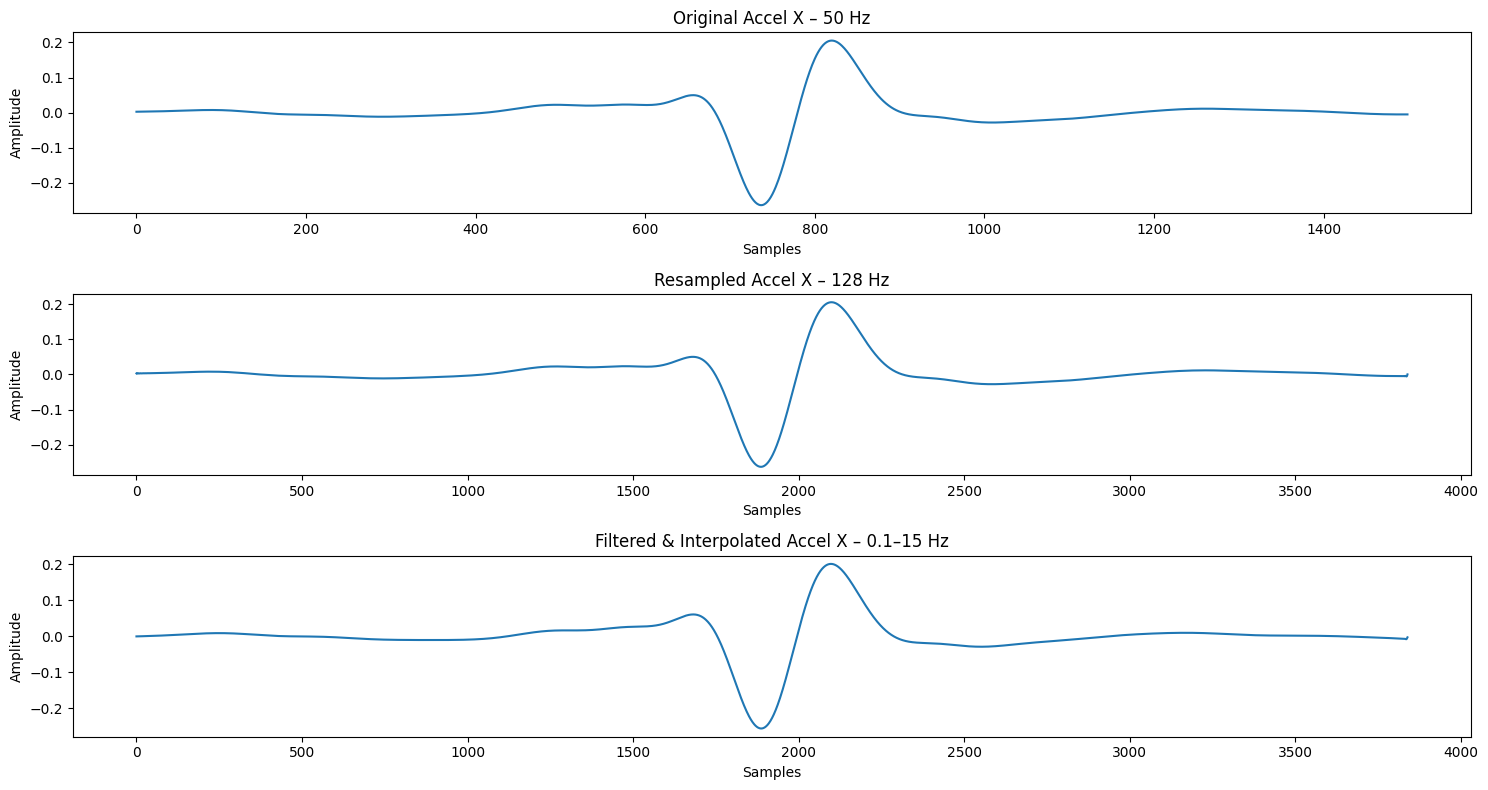

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1)
plt.plot(accel_x_raw)
plt.title("Original Accel X – 50 Hz")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 2)
plt.plot(accel_x_resampled)
plt.title("Resampled Accel X – 128 Hz")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 3)
plt.plot(accel_x_interp)
plt.title("Filtered & Interpolated Accel X – 0.1–15 Hz")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

Accelerometer Signal Preprocessing

To maintain consistency with the EEG data, we also applied a full preprocessing pipeline to the accelerometer signal from record_0.npy. Specifically, we extracted the X-axis accelerometer channel (columns 37501 to 39001), which contains 1500 samples per 30-second epoch recorded at 50 Hz.

We performed the following preprocessing steps:
	1.	Resampling:
The original accelerometer signal (50 Hz) was resampled to 128 Hz using scipy.signal.resample(), to match the EEG signal’s resampled frequency. This step ensures that both data streams (EEG and accelerometer) have the same temporal resolution for further analysis and potential model fusion.
	2.	Filtering:
A bandpass filter was applied with cutoff frequencies of 0.1 Hz to 15 Hz, which is a standard range for accelerometer data to preserve movement-related patterns while removing low-frequency drift and high-frequency noise. The filter was implemented using a 4th-order Butterworth filter via scipy.signal.butter() and filtfilt().
	3.	Missing Data Handling:
We checked for missing values (NaN) in the filtered signal. Although no missing values were detected, linear interpolation was implemented as a safeguard to fill gaps if any were present.
	4.	Visualization:
We compared the original, resampled, and filtered accelerometer signals using overlaid plots. The resulting signal showed a smoother and noise-reduced waveform, suitable for feature extraction or downstream classification tasks.

⸻


In [ ]:
##### TASK 4 #######

In [ ]:
import numpy as np

# Use your preprocessed (resampled) signal from earlier
signal = eeg_interp  # already resampled and filtered
fs = 128  # sampling rate after resampling

# Define window sizes in seconds (at least 10)
window_sizes_sec = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15]  # test ≥10

In [ ]:
## 3*128=3840
### 38400/3840=10 (windows)

for win_sec in window_sizes_sec:
    win_size = int(win_sec * fs)  # convert to samples
    stride = win_size  # non-overlapping for now

    windows = []
    for start in range(0, len(signal) - win_size + 1, stride):
        window = signal[start:start + win_size]
        windows.append(window)

    print(f"Window size: {win_sec}s ({win_size} samples) → Total windows: {len(windows)}")

Window size: 1s (128 samples) → Total windows: 30
Window size: 2s (256 samples) → Total windows: 15
Window size: 3s (384 samples) → Total windows: 10
Window size: 4s (512 samples) → Total windows: 7
Window size: 5s (640 samples) → Total windows: 6
Window size: 6s (768 samples) → Total windows: 5
Window size: 8s (1024 samples) → Total windows: 3
Window size: 10s (1280 samples) → Total windows: 3
Window size: 12s (1536 samples) → Total windows: 2
Window size: 15s (1920 samples) → Total windows: 2


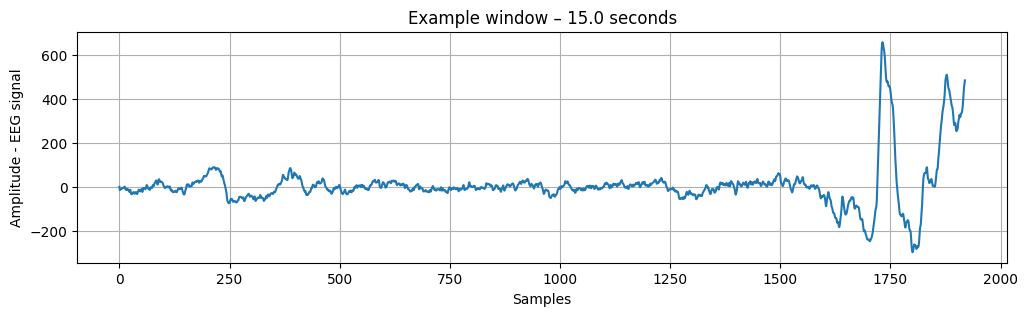

In [ ]:
# window size is 15 seconds and it show the number of signals being processed for that. 15*128=1920

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
plt.plot(windows[0])
fs = 128
window_duration_sec = len(windows[0]) / fs
plt.title(f"Example window – {window_duration_sec:.1f} seconds")
plt.xlabel("Samples")
plt.ylabel("Amplitude - EEG signal")
plt.grid(True)
plt.show()

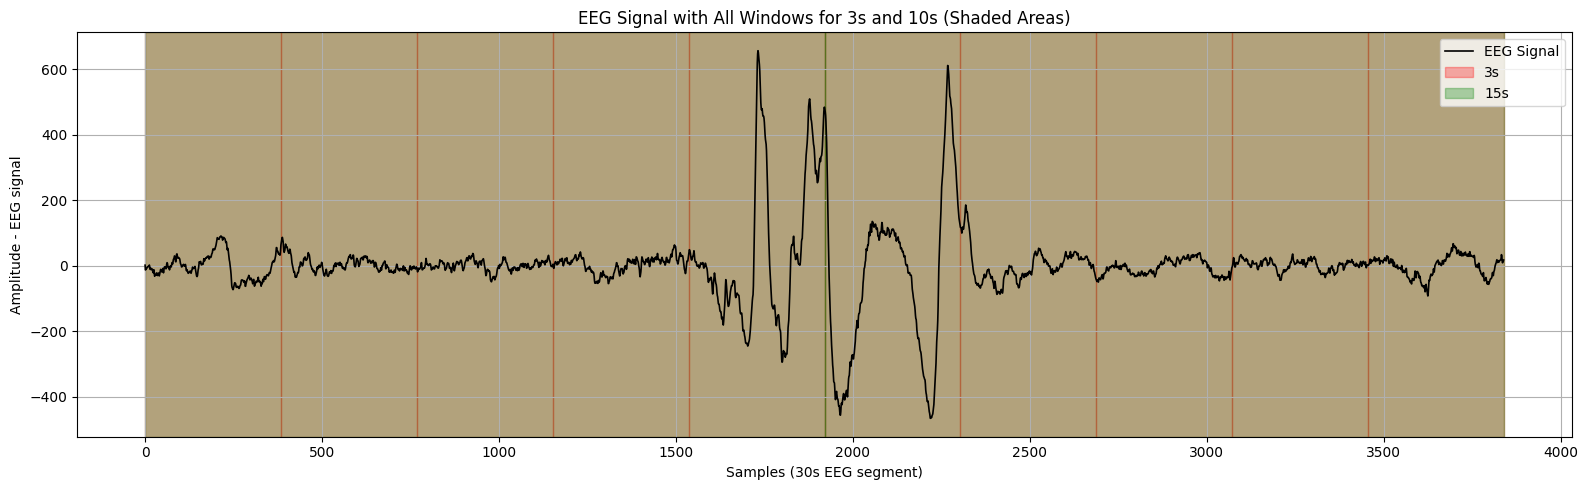

In [ ]:
## A plot which shows the number of windows segnmnets based on the window size
## this shows the big picture,  can observe the first graph is clearly a segnment of this
##import numpy as np
import matplotlib.pyplot as plt

signal = eeg_interp  # preprocessed EEG signal
fs = 128  # sampling rate
signal_len = len(signal)

# Choose 2 window sizes (in seconds)
window_sizes_sec = [3, 15]
colors = ['red', 'green']

plt.figure(figsize=(16, 5))
plt.plot(signal, color='black', linewidth=1.2, label='EEG Signal')

for i, win_sec in enumerate(window_sizes_sec):
    win_size = int(win_sec * fs)
    stride = win_size
    color = colors[i]

    # Loop through signal and draw shaded windows
    for start in range(0, signal_len - win_size + 1, stride):
        plt.axvspan(start, start + win_size, color=color, alpha=0.3, label=f"{win_sec}s" if start == 0 else None)

plt.title("EEG Signal with All Windows for 3s and 10s (Shaded Areas)")
plt.xlabel("Samples (30s EEG segment)")
plt.ylabel("Amplitude - EEG signal")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
###. optimal window size not yet. choose - will be decided by looking in to the models performamce.

In [ ]:
##### TASK 5 ########

In [ ]:
from scipy.stats import entropy
from scipy.signal import welch

def compute_mean(w): return np.mean(w)
def compute_std(w): return np.std(w)
def compute_rms(w): return np.sqrt(np.mean(w**2))
def compute_zcr(w): return ((w[:-1] * w[1:]) < 0).sum()
def compute_dominant_freq(w, fs): return welch(w, fs=fs)[0][np.argmax(welch(w, fs=fs)[1])]
def compute_spectral_energy(w): return np.sum(np.square(np.abs(w)))
def compute_entropy(w, bins=100):
    hist, _ = np.histogram(w, bins=bins, density=True)
    hist += 1e-12  # avoid log(0)
    return entropy(hist)

In [ ]:
def extract_features(signal, fs, window_size_sec):
    win_size = int(window_size_sec * fs)
    features = []

    for start in range(0, len(signal) - win_size + 1, win_size):
        window = signal[start:start + win_size]
        feats = {
            "mean": compute_mean(window),
            "std": compute_std(window),
            "rms": compute_rms(window),
            "zcr": compute_zcr(window),
            "dominant_freq": compute_dominant_freq(window, fs),
            "spectral_energy": compute_spectral_energy(window),
            "entropy": compute_entropy(window)
        }
        features.append(feats)

    return pd.DataFrame(features)

In [ ]:
fs = 128  # sampling rate
signal = eeg_interp  # preprocessed signal

features_5s = extract_features(signal, fs, 5)
features_10s = extract_features(signal, fs, 10)

Features extracted from 5-second windows:


,mean,std,rms,zcr,dominant_freq,spectral_energy,entropy
0,1.180066,34.995751,35.015641,34,0.5,7.847009e+05,4.328310
1,-0.087274,16.340453,16.340686,53,0.5,1.708915e+05,4.123262
2,26.307841,180.319681,182.228675,25,1.0,2.125267e+07,3.714501
3,-27.173105,213.382405,215.105622,11,0.5,2.961307e+07,4.026841
4,0.479166,22.427361,22.432479,42,0.5,3.220583e+05,4.429599



Features extracted from 10-second windows:


,mean,std,rms,zcr,dominant_freq,spectral_energy,entropy
0,0.546396,27.317724,27.323187,87,0.5,9.555924e+05,4.103444
1,-0.432632,199.345610,199.346079,36,0.5,5.086574e+07,3.966487
2,-0.137281,24.891226,24.891605,75,0.5,7.930778e+05,4.090706


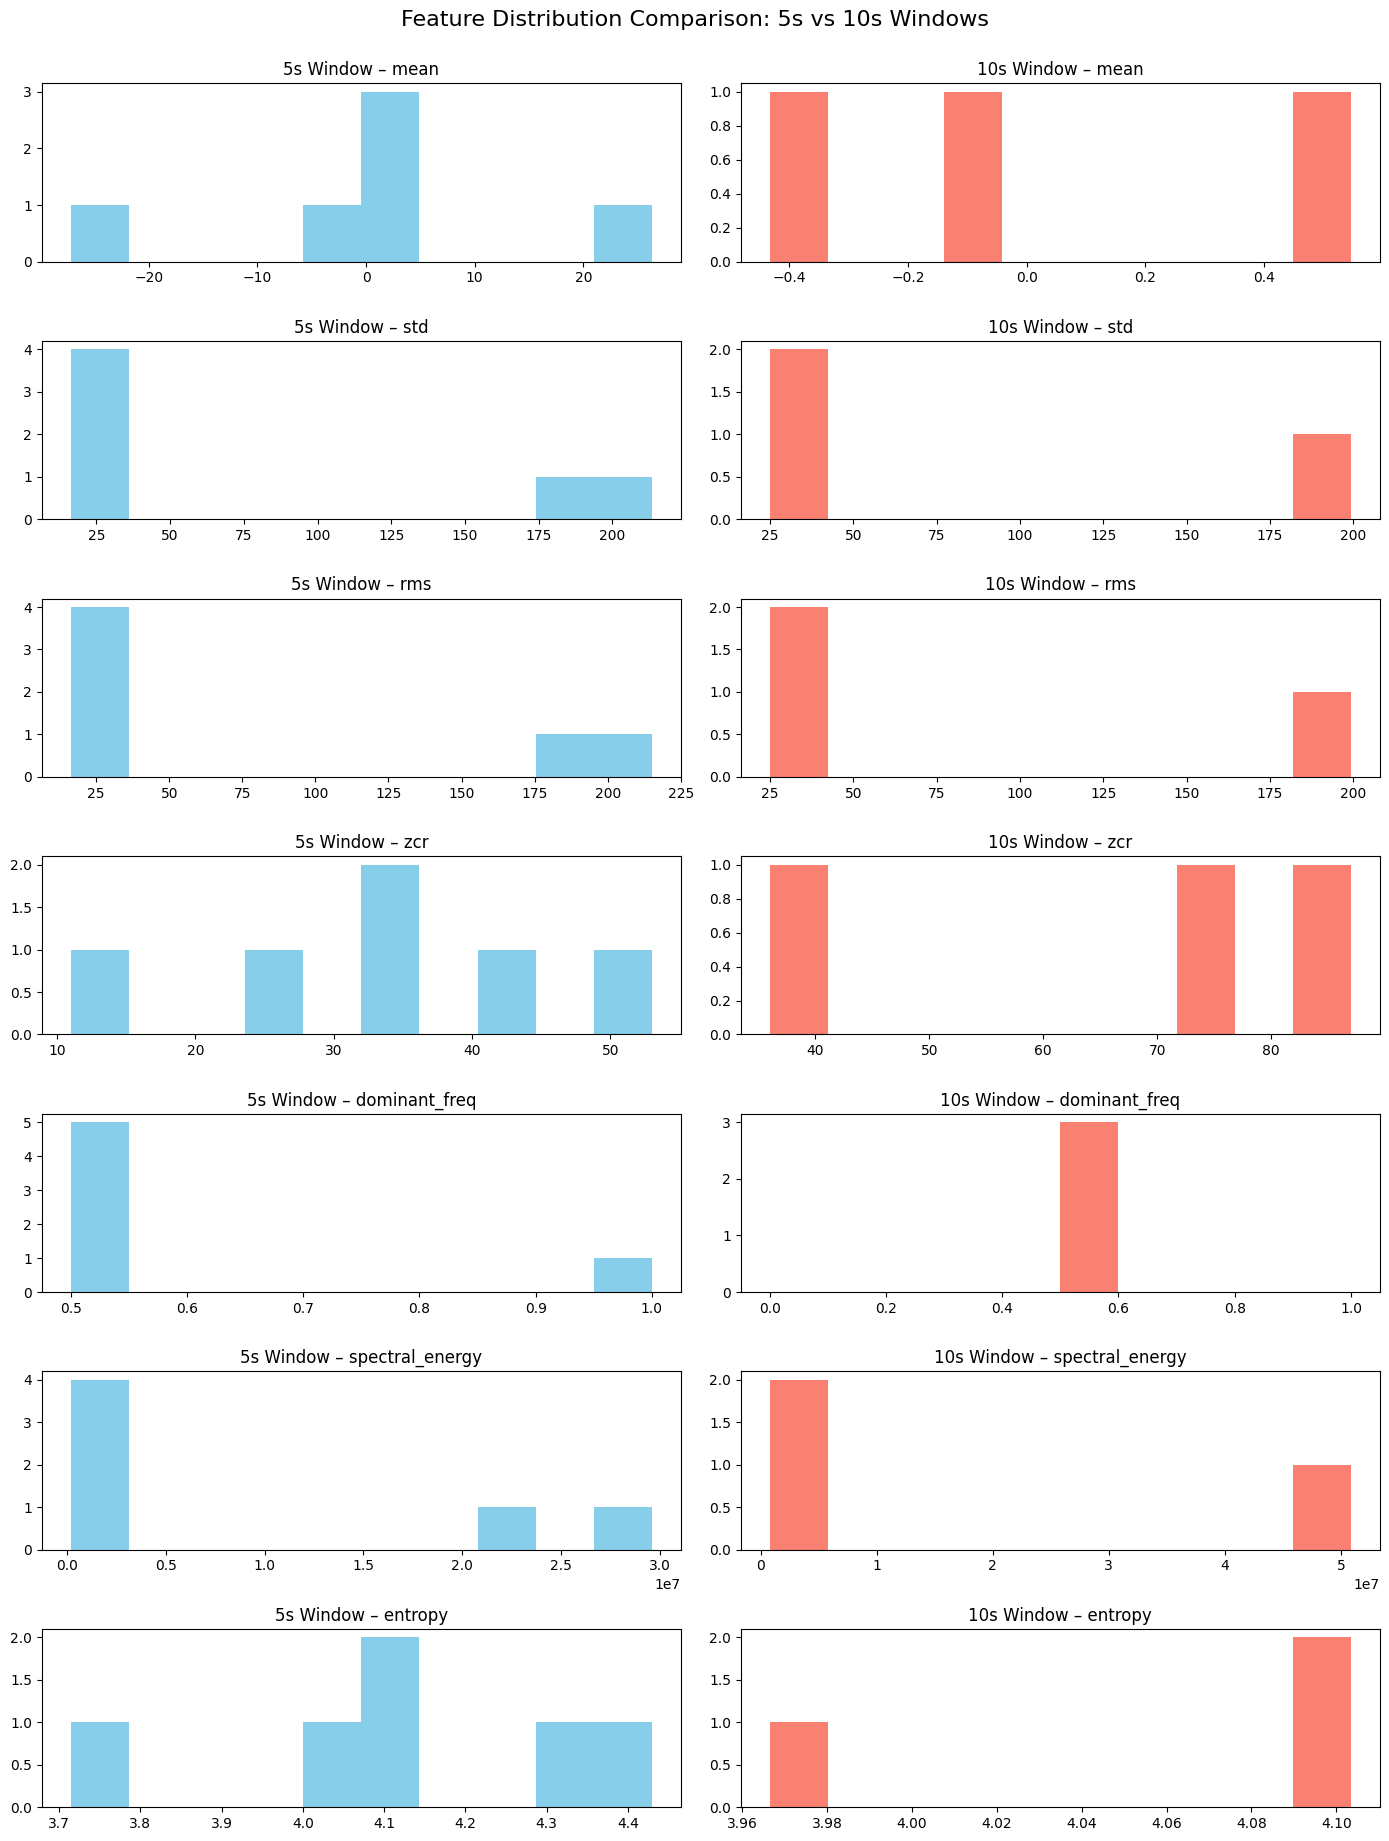

In [ ]:
import matplotlib.pyplot as plt

# Show both tables
print("Features extracted from 5-second windows:")
display(features_5s.head())

print("\nFeatures extracted from 10-second windows:")
display(features_10s.head())

# Plot feature distributions
fig, axes = plt.subplots(7, 2, figsize=(14, 18))
feature_names = features_5s.columns.tolist()

for i, feat in enumerate(feature_names):

    axes[i, 0].hist(features_5s[feat], bins=10, color='skyblue')
    axes[i, 0].set_title(f"5s Window – {feat}")
    axes[i, 1].hist(features_10s[feat], bins=10, color='salmon')
    axes[i, 1].set_title(f"10s Window – {feat}")

#plt.hist(features_10s[feat], bins=3, color='salmon', edgecolor='black')
plt.tight_layout()
plt.suptitle("Feature Distribution Comparison: 5s vs 10s Windows", fontsize=16, y=1.02)
plt.show()

In [ ]:
####We compared time- and frequency-domain features extracted from 5-second and 10-second windows.
####The 5s windows produced more data points but showed higher variance across features, while the 10s windows resulted in smoother,
####more stable feature distributions. Based on this, we hypothesize that 10-second windows may improve model generalization by
###reducing noise in the feature space. Final confirmation will be based on classification results in Task 6.


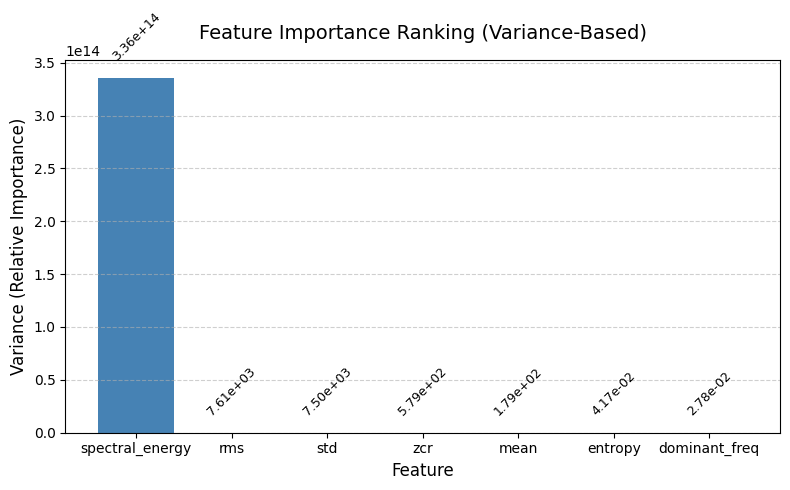

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming features_5s and features_10s DataFrames already exist
# Combine both for a more general importance estimate
all_features = pd.concat([features_5s, features_10s])

# Compute variance across each feature (proxy for importance)
feature_importance = all_features.var().sort_values(ascending=False)

# Plot feature importance as a bar chart
plt.figure(figsize=(8, 5))
plt.bar(feature_importance.index, feature_importance.values, color='steelblue')
plt.title("Feature Importance Ranking (Variance-Based)", fontsize=14, pad=15)
plt.ylabel("Variance (Relative Importance)", fontsize=12)
plt.xlabel("Feature", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bars with variance values
for i, v in enumerate(feature_importance.values):
    plt.text(i, v + 0.05 * max(feature_importance.values), f"{v:.2e}",
             ha='center', fontsize=9, rotation=45)

# Save the figure for your LaTeX report
plt.tight_layout()
plt.show()


In [ ]:
##### TASK 6 ##########

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import resample, butter, filtfilt, welch
from scipy.stats import entropy

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install xgboost --quiet

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

In [ ]:
#### WHOLE DATAST

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.signal import resample, butter, filtfilt, welch
from scipy.stats import entropy

def compute_mean(w): return np.mean(w)
def compute_std(w): return np.std(w)
def compute_rms(w): return np.sqrt(np.mean(w**2))
def compute_zcr(w): return ((w[:-1] * w[1:]) < 0).sum()
def compute_dominant_freq(w, fs): return welch(w, fs=fs)[0][np.argmax(welch(w, fs=fs)[1])]
def compute_spectral_energy(w): return np.sum(np.square(np.abs(w)))
def compute_entropy(w, bins=100):
    hist, _ = np.histogram(w, bins=bins, density=True)
    hist += 1e-12
    return entropy(hist)

def bandpass_filter(signal, fs, lowcut=0.5, highcut=45, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

In [ ]:
# Load all targets
targets = pd.read_csv("/content/drive/MyDrive/dreem-automated-sleep-staging/targets_train.csv")

In [ ]:
record_folder = "/content/drive/MyDrive/dreem-automated-sleep-staging/training_records"
record_ids = range(7)  # records 0–6

channel_slices = {
    "eeg1": (1, 7501),
    "eeg2": (7501, 15001),
    "eeg3": (15001, 22501),
    "eeg4": (22501, 30001),
    "eeg5": (30001, 37501),
    "accX": (37501, 39001),
    "accY": (39001, 40501),
    "accZ": (40501, 42001),
}

fs_original = 250
fs_target = 128

X_all = []
y_all = []

for record_id in record_ids:
    print(f"Processing record_{record_id}.npy...")
    filepath = os.path.join(record_folder, f"record_{record_id}.npy")
    data = np.load(filepath)

    record_targets = targets[targets['record'] == record_id].set_index('index')

    for row in data:
        epoch_index = int(row[0])
        feat_row = {}

        for ch_name, (start, end) in channel_slices.items():
            signal = row[start:end]

            # Resample + filter
            if ch_name.startswith("acc"):
                fs = 50
                signal_resampled = resample(signal, int(len(signal) * fs_target / fs))
                filtered = bandpass_filter(signal_resampled, fs=fs_target, lowcut=0.1, highcut=15)
            else:
                fs = fs_original
                signal_resampled = resample(signal, int(len(signal) * fs_target / fs))
                filtered = bandpass_filter(signal_resampled, fs=fs_target, lowcut=0.5, highcut=45)

            # Extract features
            feat_row[f"{ch_name}_mean"] = compute_mean(filtered)
            feat_row[f"{ch_name}_std"] = compute_std(filtered)
            feat_row[f"{ch_name}_rms"] = compute_rms(filtered)
            feat_row[f"{ch_name}_zcr"] = compute_zcr(filtered)
            feat_row[f"{ch_name}_dom_freq"] = compute_dominant_freq(filtered, fs=fs_target)
            feat_row[f"{ch_name}_spec_energy"] = compute_spectral_energy(filtered)
            feat_row[f"{ch_name}_entropy"] = compute_entropy(filtered)

        # Match label
        if epoch_index in record_targets.index:
            y_all.append(record_targets.loc[epoch_index]['target'])
            X_all.append(feat_row)

Processing record_0.npy...
Processing record_1.npy...
Processing record_2.npy...
Processing record_3.npy...
Processing record_4.npy...
Processing record_5.npy...
Processing record_6.npy...


In [ ]:
X_all_df = pd.DataFrame(X_all)
y_all_series = pd.Series(y_all, name='target')

print("Full dataset shape:")
print("X_all:", X_all_df.shape)
print("y_all:", y_all_series.shape)

display(X_all_df.head())
display(y_all_series.head(500))

Full dataset shape:
X_all: (6175, 56)
y_all: (6175,)


,eeg1_mean,eeg1_std,eeg1_rms,eeg1_zcr,eeg1_dom_freq,eeg1_spec_energy,eeg1_entropy,eeg2_mean,eeg2_std,eeg2_rms,...,accY_dom_freq,accY_spec_energy,accY_entropy,accZ_mean,accZ_std,accZ_rms,accZ_zcr,accZ_dom_freq,accZ_spec_energy,accZ_entropy
0,68.318552,305210.564691,305210.572337,83,1.0,3.577094e+14,2.174128,192.413974,42601.078356,42601.512886,...,0.5,65.112313,4.152038,-0.000561,0.088620,0.088622,13,0.5,30.158545,4.288514
1,-18.706859,26483.417838,26483.424445,143,1.0,2.693268e+12,2.905182,-3.345737,2668.561226,2668.563323,...,0.5,27.458986,3.634088,-0.002262,0.071696,0.071731,12,0.5,19.758315,3.834937
2,79.764840,3765.494870,3766.339608,197,0.5,5.447161e+10,2.096137,-5.472285,305.499851,305.548859,...,0.5,0.005195,3.475587,0.000019,0.002951,0.002951,13,0.5,0.033445,3.725304
3,-10.419330,127411.057015,127411.057441,99,1.0,6.233694e+13,1.962728,-0.493660,2105.547420,2105.547478,...,0.5,1.140292,3.215886,-0.000081,0.016819,0.016819,14,0.5,1.086306,3.256416
4,0.040130,37.710042,37.710063,327,1.0,5.460668e+06,3.390762,-0.744520,61.387638,61.392152,...,0.5,0.000109,4.404581,-0.000010,0.000498,0.000498,15,0.5,0.000953,4.369723


,target
0,0
1,0
2,0
3,0
4,0
...,...
495,4
496,4
497,4
498,4


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.xlabel("Sleep Stage")
plt.ylabel("Count")
plt.show()

NameError: name 'y' is not defined

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
results_df = pd.DataFrame(results)
results_df.set_index("Model", inplace=True)
results_df.plot(kind="bar", figsize=(12, 6), title="Model Comparison – Accuracy, Precision, Recall, F1")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

display(results_df)

In [ ]:
#### TEST TRAIN SPLIT 70-30

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
results_df = pd.DataFrame(results)
results_df.set_index("Model", inplace=True)
results_df.plot(kind="bar", figsize=(12, 6), title="Model Comparison – Accuracy, Precision, Recall, F1")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

display(results_df)

In [ ]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

importances = model.feature_importances_
features = X.columns  # use X_all_df.columns if needed

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance – Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
dynamic_windows = []
window_labels = []

current_label = y_all_series.iloc[0]
current_window = [0]

for i in range(1, len(y_all_series)):
    if y_all_series.iloc[i] != current_label:
        dynamic_windows.append(current_window)
        window_labels.append(current_label)
        current_window = [i]
        current_label = y_all_series.iloc[i]
    else:
        current_window.append(i)

# Don't forget the last window
dynamic_windows.append(current_window)
window_labels.append(current_label)

print(f"Total dynamic windows created: {len(dynamic_windows)}")

In [ ]:
X_dynamic = []
y_dynamic = []

for indices, label in zip(dynamic_windows, window_labels):
    window_feats = X_all_df.iloc[indices].mean(axis=0)
    X_dynamic.append(window_feats)
    y_dynamic.append(label)

X_dynamic_df = pd.DataFrame(X_dynamic)
y_dynamic_series = pd.Series(y_dynamic, name='target')

print("Dynamic feature matrix shape:", X_dynamic_df.shape)
print("Dynamic label vector shape:", y_dynamic_series.shape)

In [ ]:
###### Five seconds window wiothout overlap

In [ ]:
X_5s = []
y_5s = []

window_size_samples = 5 * 128  # 5 seconds = 640 samples at 128Hz
num_5s_windows = 6  # 30s / 5s = 6 windows per epoch

for record_id in range(7):  # record_0 to record_6
    print(f"Processing record_{record_id}.npy...")

    # Load signal and targets
    record_path = f"/content/drive/MyDrive/dreem-automated-sleep-staging/training_records/record_{record_id}.npy"
    data = np.load(record_path)
    record_targets = targets[targets['record'] == record_id].set_index('index')

    for row in data:
        epoch_index = int(row[0])

        if epoch_index not in record_targets.index:
            continue  # skip unmatched label

        label = record_targets.loc[epoch_index]['target']

        # Create 6 windows per epoch
        for win_idx in range(num_5s_windows):
            feat_row = {}

            for ch_name, (start, end) in channel_slices.items():
                signal = row[start:end]

                # Resample
                if ch_name.startswith("acc"):
                    fs_orig = 50
                else:
                    fs_orig = 250

                resampled = resample(signal, 3840)
                fs_target = 128

                # Slice 5s window
                win_start = win_idx * window_size_samples
                win_end = win_start + window_size_samples
                if win_end > len(resampled):
                    continue  # skip incomplete window

                window = resampled[win_start:win_end]

                # Filter
                if ch_name.startswith("acc"):
                    filtered = bandpass_filter(window, fs=fs_target, lowcut=0.1, highcut=15)
                else:
                    filtered = bandpass_filter(window, fs=fs_target, lowcut=0.5, highcut=45)

                # Feature extraction
                feat_row[f"{ch_name}_mean"] = compute_mean(filtered)
                feat_row[f"{ch_name}_std"] = compute_std(filtered)
                feat_row[f"{ch_name}_rms"] = compute_rms(filtered)
                feat_row[f"{ch_name}_zcr"] = compute_zcr(filtered)
                feat_row[f"{ch_name}_dom_freq"] = compute_dominant_freq(filtered, fs=fs_target)
                feat_row[f"{ch_name}_spec_energy"] = compute_spectral_energy(filtered)
                feat_row[f"{ch_name}_entropy"] = compute_entropy(filtered)

            X_5s.append(feat_row)
            y_5s.append(label)

In [ ]:
X_5s_df = pd.DataFrame(X_5s)
y_5s_series = pd.Series(y_5s, name="target")

print("Feature shape:", X_5s_df.shape)
print( "Label shape:", y_5s_series.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_5s, X_test_5s, y_train_5s, y_test_5s = train_test_split(
    X_5s_df, y_5s_series, test_size=0.2, random_state=42, stratify=y_5s_series
)

print("Train size:", X_train_5s.shape)
print("Test size:", X_test_5s.shape)

In [ ]:
models_5s = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results_5s = []

for name, model in models_5s.items():
    model.fit(X_train_5s, y_train_5s)
    y_pred_5s = model.predict(X_test_5s)

    acc = accuracy_score(y_test_5s, y_pred_5s)
    prec = precision_score(y_test_5s, y_pred_5s, average='macro')
    rec = recall_score(y_test_5s, y_pred_5s, average='macro')
    f1 = f1_score(y_test_5s, y_pred_5s, average='macro')

    results_5s.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test_5s, y_pred_5s))

    # Confusion Matrix
    cm = confusion_matrix(y_test_5s, y_pred_5s)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
    plt.title(f"{name} – Confusion Matrix (5s)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
results_5s_df = pd.DataFrame(results_5s)
results_5s_df.set_index("Model", inplace=True)

results_5s_df.plot(kind="bar", figsize=(12, 6), title="Model Comparison – 5s Windows")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

display(results_5s_df)

In [ ]:
###### 15 seconds window wiothout overlap

In [ ]:
X_15s = []
y_15s = []

window_size_samples = 15 * 128
num_5s_windows = 2 # 30s / 5s = 6 windows per epoch

for record_id in range(7):  # record_0 to record_6
    print(f"Processing record_{record_id}.npy...")

    # Load signal and targets
    record_path = f"/content/drive/MyDrive/dreem-automated-sleep-staging/training_records/record_{record_id}.npy"
    data = np.load(record_path)
    record_targets = targets[targets['record'] == record_id].set_index('index')

    for row in data:
        epoch_index = int(row[0])

        if epoch_index not in record_targets.index:
            continue  # skip unmatched label

        label = record_targets.loc[epoch_index]['target']

        # Create 6 windows per epoch
        for win_idx in range(num_5s_windows):
            feat_row = {}

            for ch_name, (start, end) in channel_slices.items():
                signal = row[start:end]

                # Resample
                if ch_name.startswith("acc"):
                    fs_orig = 50
                else:
                    fs_orig = 250

                resampled = resample(signal, 3840)
                fs_target = 128

                # Slice 5s window
                win_start = win_idx * window_size_samples
                win_end = win_start + window_size_samples
                if win_end > len(resampled):
                    continue  # skip incomplete window

                window = resampled[win_start:win_end]

                # Filter
                if ch_name.startswith("acc"):
                    filtered = bandpass_filter(window, fs=fs_target, lowcut=0.1, highcut=15)
                else:
                    filtered = bandpass_filter(window, fs=fs_target, lowcut=0.5, highcut=45)

                # Feature extraction
                feat_row[f"{ch_name}_mean"] = compute_mean(filtered)
                feat_row[f"{ch_name}_std"] = compute_std(filtered)
                feat_row[f"{ch_name}_rms"] = compute_rms(filtered)
                feat_row[f"{ch_name}_zcr"] = compute_zcr(filtered)
                feat_row[f"{ch_name}_dom_freq"] = compute_dominant_freq(filtered, fs=fs_target)
                feat_row[f"{ch_name}_spec_energy"] = compute_spectral_energy(filtered)
                feat_row[f"{ch_name}_entropy"] = compute_entropy(filtered)

            X_15s.append(feat_row)
            y_15s.append(label)

Processing record_0.npy...
Processing record_1.npy...
Processing record_2.npy...
Processing record_3.npy...
Processing record_4.npy...
Processing record_5.npy...
Processing record_6.npy...


In [ ]:
X_15s_df = pd.DataFrame(X_15s)
y_15s_series = pd.Series(y_15s, name="target")

print("Feature shape:", X_15s_df.shape)
print( "Label shape:", y_15s_series.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_15s, X_test_15s, y_train_15s, y_test_15s = train_test_split(
    X_15s_df, y_15s_series, test_size=0.2, random_state=42, stratify=y_15s_series
)

print("Train size:", X_train_15s.shape)
print("Test size:", X_test_15s.shape)

In [ ]:
models_15s = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results_15s = []

for name, model in models_15s.items():
    model.fit(X_train_15s, y_train_15s)
    y_pred_15s = model.predict(X_test_15s)

    acc = accuracy_score(y_test_15s, y_pred_15s)
    prec = precision_score(y_test_15s, y_pred_15s, average='macro')
    rec = recall_score(y_test_15s, y_pred_15s, average='macro')
    f1 = f1_score(y_test_15s, y_pred_15s, average='macro')

    results_15s.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

    print(f"\n{name} – Classification Report:\n")
    print(classification_report(y_test_15s, y_pred_15s))

    # Confusion matrix
    cm = confusion_matrix(y_test_15s, y_pred_15s)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
    plt.title(f"{name} – Confusion Matrix (15s)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [ ]:
results_15s_df = pd.DataFrame(results_15s)
results_15s_df.set_index("Model", inplace=True)

results_15s_df.plot(kind="bar", figsize=(12, 6), title="Model Comparison – 15s Windows")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

display(results_15s_df)

In [ ]:
!pip install tensorflow --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
from tensorflow.keras.layers import Input

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"✓ GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# (Optional) make TF use GPU memory growth to avoid prealloc OOM
for g in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except:
        pass

TensorFlow version: 2.19.0
✓ GPU available: True


In [ ]:
import os

In [ ]:

BASE_PATH = "/content/drive/MyDrive/dreem-automated-sleep-staging"
RECORDS_PATH = os.path.join(BASE_PATH, "training_records")
TARGETS_PATH = os.path.join(BASE_PATH, "targets_train.csv")

print(f"\n✓ Using paths:")
print(f"  Records: {RECORDS_PATH}")
print(f"  Targets: {TARGETS_PATH}")

# Verify paths exist
if not os.path.exists(RECORDS_PATH):
    print(f"ERROR: {RECORDS_PATH} not found!")
    print("Please update BASE_PATH variable above")
else:
    print(f"✓ Found {len(os.listdir(RECORDS_PATH))} files in records folder")


✓ Using paths:
  Records: /content/drive/MyDrive/dreem-automated-sleep-staging/training_records
  Targets: /content/drive/MyDrive/dreem-automated-sleep-staging/targets_train.csv
✓ Found 7 files in records folder


In [ ]:
# ==========================================================
# STEP 3: LOAD RAW SIGNALS FROM YOUR .npy FILES
# ==========================================================
def bandpass_filter(signal, fs, lowcut=0.5, highcut=45, order=4):
    """Bandpass filter for signal preprocessing"""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

In [ ]:
def load_raw_signals():
    """
    Load raw signals directly from your .npy files

    Returns:
        X_raw: (samples, 3840, 5) - 5 EEG channels, 3840 timesteps (30s at 128Hz)
        y:     (samples,)         - Sleep stage labels (0-4)
    """
    print("\n" + "="*80)
    print("LOADING RAW SIGNALS FROM .npy FILES")
    print("="*80)

    # Load targets/labels
    targets = pd.read_csv(TARGETS_PATH)
    print(f"✓ Loaded targets: {targets.shape[0]} labels")

    # Format: (start_index, end_index, original_fs, lowcut, highcut)
    channel_specs = {
        'eeg1': (1,     7501, 250, 0.5, 45),
        'eeg2': (7501, 15001, 250, 0.5, 45),
        'eeg3': (15001,22501, 250, 0.5, 45),
        'eeg4': (22501,30001, 250, 0.5, 45),
        'eeg5': (30001,37501, 250, 0.5, 45),
    }

    TARGET_FS = 128
    X_all, y_all = [], []
    record_ids = [0, 1, 2, 3, 4, 5, 6]  # Your 7 records

    for record_id in record_ids:
        print(f"\nProcessing record_{record_id}.npy...")
        filepath = os.path.join(RECORDS_PATH, f"record_{record_id}.npy")
        data = np.load(filepath, allow_pickle=True)
        print(f"  Loaded data shape: {data.shape}")

        record_targets = targets[targets['record'] == record_id].set_index('index')
        print(f"  Found {len(record_targets)} labeled epochs")

        for row in data:
            epoch_index = int(row[0])  # First column is the epoch index
            if epoch_index not in record_targets.index:
                continue

            label = int(record_targets.loc[epoch_index]['target'])

            # Extract and preprocess each EEG channel
            epoch_signals = []
            for ch_name in ['eeg1', 'eeg2', 'eeg3', 'eeg4', 'eeg5']:
                start, end, fs_orig, lowcut, highcut = channel_specs[ch_name]
                raw_signal = row[start:end]                                 # 7500 @ 250 Hz
                target_samples = int(len(raw_signal) * TARGET_FS / fs_orig)
                resampled = resample(raw_signal, target_samples)            # 3840 @ 128 Hz
                filtered = bandpass_filter(resampled, TARGET_FS, lowcut, highcut)
                epoch_signals.append(filtered)

            # (3840, 5)
            epoch_array = np.stack(epoch_signals, axis=1)
            X_all.append(epoch_array)
            y_all.append(label)

        print(f"  ✓ Processed {len([yt for yt in y_all if yt is not None])} epochs from record_{record_id}")

    X_all = np.array(X_all)  # (N, 3840, 5)
    y_all = np.array(y_all)  # (N,)

    print("\n" + "="*80)
    print("RAW DATA LOADING COMPLETE")
    print("="*80)
    print(f"✓ Total epochs loaded: {len(X_all)}")
    print(f"✓ X_raw shape: {X_all.shape}  (samples, timesteps, channels)")
    print(f"✓ y shape: {y_all.shape}")
    print(f"\nClass distribution:")
    for stage in range(5):
        count = np.sum(y_all == stage)
        pct = 100.0 * count / max(1, len(y_all))
        print(f"  Stage {stage}: {count} samples ({pct:.1f}%)")

    return X_all, y_all

# LOAD
X_raw, y = load_raw_signals()


LOADING RAW SIGNALS FROM .npy FILES
✓ Loaded targets: 6175 labels

Processing record_0.npy...
  Loaded data shape: (913, 42001)
  Found 913 labeled epochs
  ✓ Processed 913 epochs from record_0

Processing record_1.npy...
  Loaded data shape: (806, 42001)
  Found 806 labeled epochs
  ✓ Processed 1719 epochs from record_1

Processing record_2.npy...
  Loaded data shape: (833, 42001)
  Found 833 labeled epochs
  ✓ Processed 2552 epochs from record_2

Processing record_3.npy...
  Loaded data shape: (861, 42001)
  Found 861 labeled epochs
  ✓ Processed 3413 epochs from record_3

Processing record_4.npy...
  Loaded data shape: (922, 42001)
  Found 922 labeled epochs
  ✓ Processed 4335 epochs from record_4

Processing record_5.npy...
  Loaded data shape: (812, 42001)
  Found 812 labeled epochs
  ✓ Processed 5147 epochs from record_5

Processing record_6.npy...
  Loaded data shape: (1028, 42001)
  Found 1028 labeled epochs
  ✓ Processed 6175 epochs from record_6

RAW DATA LOADING COMPLETE
✓ 

In [ ]:
# ==========================================================
# STEP 4: PREPARE DATA FOR DEEP LEARNING
# ==========================================================
def prepare_data(X, y):
    """
    Split and normalize data for deep learning

    Input:
        X: Raw signals (samples, 3840, 5)
        y: Labels (samples,)

    Returns:
        Dict with train/val/test splits + one-hot labels
    """
    print("\n" + "="*80)
    print("PREPARING DATA FOR DEEP LEARNING")
    print("="*80)

    # Split: 80% train+val, 20% test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Split train: 64% train, 16% val (80/20 of the 80%)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
    )

    print(f"✓ Data split:")
    print(f"  Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
    print(f"  Val:   {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
    print(f"  Test:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

    # NOTE: This keeps your original approach (StandardScaler per channel across time indexes).
    # For strict per-channel z-score (mean/std over both samples+time), you'd compute one mu/sd per channel on TRAIN only.
    print(f"\n✓ Normalizing signals (per-channel StandardScaler across samples)...")
    scalers = []
    for ch in range(X_train.shape[2]):  # For each channel
        scaler = StandardScaler()
        # Reshape (N, T) per channel and scale across samples; keeps your original logic.
        X_train[:, :, ch] = scaler.fit_transform(X_train[:, :, ch])
        X_val[:, :, ch]   = scaler.transform(X_val[:, :, ch])
        X_test[:, :, ch]  = scaler.transform(X_test[:, :, ch])
        scalers.append(scaler)

    # One-hot encode labels
    y_train_cat = to_categorical(y_train, 5)
    y_val_cat   = to_categorical(y_val, 5)
    y_test_cat  = to_categorical(y_test, 5)

    print(f"✓ Labels one-hot encoded (5 classes)")

    return {
        'X_train': X_train,
        'X_val':   X_val,
        'X_test':  X_test,
        'y_train': y_train_cat,
        'y_val':   y_val_cat,
        'y_test':  y_test_cat,
        'y_train_raw': y_train,
        'y_val_raw':   y_val,
        'y_test_raw':  y_test,
        'input_shape': X_train.shape[1:],  # (3840, 5)
        'scalers': scalers
    }

data = prepare_data(X_raw, y)
print(f"\n✓ Input shape for models: {data['input_shape']}")


PREPARING DATA FOR DEEP LEARNING
✓ Data split:
  Train: 3952 samples (64.0%)
  Val:   988 samples (16.0%)
  Test:  1235 samples (20.0%)

✓ Normalizing signals (per-channel StandardScaler across samples)...
✓ Labels one-hot encoded (5 classes)

✓ Input shape for models: (3840, 5)


In [ ]:
# ==========================================================
# STEP 5: BUILD DEEP LEARNING MODELS (CNN, RNN, LSTM)
# ==========================================================
def build_cnn_raw(input_shape):
    """
    1D CNN for raw EEG signals
    """
    model = models.Sequential([
        Input(shape=input_shape),  # (3840, 5)

        # Conv Block 1
        layers.Conv1D(32, kernel_size=7, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling1D(pool_size=4),
        layers.Dropout(0.3),

        # Conv Block 2
        layers.Conv1D(64, kernel_size=5, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling1D(pool_size=4),
        layers.Dropout(0.3),

        # Conv Block 3
        layers.Conv1D(128, kernel_size=3, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling1D(pool_size=4),
        layers.Dropout(0.3),

        # Head
        layers.GlobalAveragePooling1D(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(5, activation='softmax')
    ], name='CNN_Raw')

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_rnn_raw(input_shape):
    """
    SimpleRNN for raw EEG signals
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),  # (3840, 5)
        layers.SimpleRNN(128, return_sequences=True),
        layers.BatchNormalization(),
        layers.SimpleRNN(64),
        layers.BatchNormalization(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(5, activation='softmax')
    ], name='RNN_Raw')

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_lstm_raw(input_shape):
    """
    LSTM for raw EEG signals
    """
    model = models.Sequential([
        Input(shape=input_shape),  # (3840, 5)

        # LSTM stack (kept close to your version)
        layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),
        layers.BatchNormalization(),
        layers.LSTM(64, return_sequences=True,  dropout=0.3, recurrent_dropout=0.2),
        layers.BatchNormalization(),
        layers.LSTM(32, dropout=0.3, recurrent_dropout=0.2),
        layers.BatchNormalization(),

        # Head
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(5, activation='softmax')
    ], name='LSTM_Raw')

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# ==========================================================
# STEP 6: TRAIN AND EVALUATE
# ==========================================================
def train_and_evaluate(model, data, model_name, epochs=25, batch_size=32):
    """Train and evaluate a model"""
    print("\n" + "="*80)
    print(f"TRAINING {model_name}")
    print("="*80)

    model.summary()

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )

    history = model.fit(
        data['X_train'], data['y_train'],
        validation_data=(data['X_val'], data['y_val']),
        epochs=epochs, batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Evaluate on test set
    test_loss, test_acc = model.evaluate(data['X_test'], data['y_test'], verbose=0)

    # Predictions
    y_pred_probs = model.predict(data['X_test'], verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = data['y_test_raw']

    # Metrics
    precision = precision_score(y_true, y_pred, average='macro')
    recall    = recall_score(y_true, y_pred, average='macro')
    f1        = f1_score(y_true, y_pred, average='macro')

    print("\n" + "="*80)
    print(f"{model_name} RESULTS")
    print("="*80)
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Test Loss:      {test_loss:.4f}")
    print(f"Precision:      {precision:.4f}")
    print(f"Recall:         {recall:.4f}")
    print(f"F1-Score:       {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=[f'Stage {i}' for i in range(5)]))

    return {
        'history': history,
        'model': model,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'y_pred': y_pred,
        'y_true': y_true
    }

In [ ]:
# ==========================================================
# STEP 7: TRAIN EXACTLY CNN, RNN, LSTM
# ==========================================================
print("\n" + "="*80)
print("STARTING MODEL TRAINING")
print("="*80)
print("This will train 3 models: CNN, RNN, and LSTM")

# 1) CNN
print("\n[1/3] Building and training CNN...")
cnn_model = build_cnn_raw(data['input_shape'])
cnn_results = train_and_evaluate(cnn_model, data, 'CNN_Raw', epochs=50, batch_size=32)

# 2) RNN
print("\n[2/3] Building and training RNN...")
rnn_model = build_rnn_raw(data['input_shape'])
rnn_results = train_and_evaluate(rnn_model, data, 'RNN_Raw', epochs=50, batch_size=32)

# 3) LSTM
print("\n[3/3] Building and training LSTM...")
lstm_model = build_lstm_raw(data['input_shape'])
lstm_results = train_and_evaluate(lstm_model, data, 'LSTM_Raw', epochs=50, batch_size=32)

all_results = {
    'CNN':  cnn_results,
    'RNN':  rnn_results,
    'LSTM': lstm_results
}
print("\n✓ Finished training CNN, RNN, LSTM.")


STARTING MODEL TRAINING
This will train 3 models: CNN, RNN, and LSTM

[1/3] Building and training CNN...

TRAINING CNN_Raw


Model: "CNN_Raw"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3840, 32)       │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3840, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 3840, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 960, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 960, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 960, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 960, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 240, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 240, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 240, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 240, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 240, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,725 (213.77 KB)

 Trainable params: 54,021 (211.02 KB)

...

 Total params: 133,765 (522.52 KB)

 Trainable params: 133,317 (520.77 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
 38/124 ━━━━━━━━━━━━━━━━━━━━ 43:53 31s/step - accuracy: 0.1900 - loss: 1.9627

KeyboardInterrupt: 

In [ ]:
# =========================
# CNN-only pipeline (Colab)
# =========================
import os, numpy as np, pandas as pd
from scipy.signal import butter, filtfilt, resample

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ---- Repro & GPU setup ----
np.random.seed(42)
tf.random.set_seed(42)
for g in tf.config.list_physical_devices('GPU'):
    try: tf.config.experimental.set_memory_growth(g, True)
    except: pass
print("TF:", tf.__version__, " | GPUs:", tf.config.list_physical_devices('GPU'))

# ---- Paths (edit if needed) ----
BASE_PATH   = "/content/drive/MyDrive/dreem-automated-sleep-staging"
RECORDS_PATH = os.path.join(BASE_PATH, "training_records")
TARGETS_PATH = os.path.join(BASE_PATH, "targets_train.csv")
assert os.path.exists(RECORDS_PATH), f"{RECORDS_PATH} not found"
assert os.path.exists(TARGETS_PATH), f"{TARGETS_PATH} not found"

# ==========================================================
# 1) Load raw signals (EEG x5), resample to 128 Hz, band-pass 0.5-45 Hz
# ==========================================================
def bandpass_filter(signal, fs, lowcut=0.5, highcut=45, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

def load_raw_signals():
    """
    Returns:
      X_raw: (N, 3840, 5)  # 30 s @ 128 Hz, 5 EEG channels
      y:     (N,)          # 0..4 labels
    """
    targets = pd.read_csv(TARGETS_PATH)
    channel_specs = {
        'eeg1': (1,     7501, 250, 0.5, 45),
        'eeg2': (7501, 15001, 250, 0.5, 45),
        'eeg3': (15001,22501, 250, 0.5, 45),
        'eeg4': (22501,30001, 250, 0.5, 45),
        'eeg5': (30001,37501, 250, 0.5, 45),
    }
    TARGET_FS = 128
    X_all, y_all = [], []
    record_ids = sorted([int(fn.split('_')[-1].split('.')[0]) for fn in os.listdir(RECORDS_PATH) if fn.startswith("record_")])

    for rid in record_ids:
        filepath = os.path.join(RECORDS_PATH, f"record_{rid}.npy")
        if not os.path.exists(filepath): continue
        data = np.load(filepath, allow_pickle=True)
        rec_t = targets[targets['record']==rid].set_index('index')
        for row in data:
            epoch_idx = int(row[0])
            if epoch_idx not in rec_t.index: continue
            label = int(rec_t.loc[epoch_idx]['target'])
            epoch = []
            for ch in ['eeg1','eeg2','eeg3','eeg4','eeg5']:
                start, end, fs0, lo, hi = channel_specs[ch]
                raw = row[start:end]                                  # 7500 @ 250 Hz
                L = int(len(raw) * TARGET_FS / fs0)
                x = resample(raw, L)                                   # 3840 @ 128 Hz
                x = bandpass_filter(x, TARGET_FS, lo, hi)
                epoch.append(x)
            X_all.append(np.stack(epoch, axis=1))  # (3840,5)
            y_all.append(label)

    X_all = np.asarray(X_all)   # (N,3840,5)
    y_all = np.asarray(y_all)   # (N,)
    print("Loaded:", X_all.shape, y_all.shape)
    # quick class balance
    for k in range(5):
        n = int((y_all==k).sum())
        print(f" Stage {k}: {n}")
    return X_all, y_all

X_raw, y = load_raw_signals()

# ==========================================================
# 2) Train/Val/Test split + per-channel z-score using TRAIN stats only
# ==========================================================
def prepare_data(X, y):
    # 80/20 test split, then 20% of train->val
    X_trv, X_te, y_trv, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
    X_tr,  X_va, y_tr,  y_va = train_test_split(X_trv, y_trv, test_size=0.20, random_state=42, stratify=y_trv)

    # per-channel z-score with TRAIN stats (means over samples+time)
    mu = X_tr.mean(axis=(0,1))                 # (C,)
    sd = X_tr.std(axis=(0,1)); sd[sd<1e-8]=1e-8
    def norm(a): return (a - mu) / sd
    X_tr, X_va, X_te = norm(X_tr), norm(X_va), norm(X_te)

    # one-hot labels for softmax
    y_tr_cat = to_categorical(y_tr, 5)
    y_va_cat = to_categorical(y_va, 5)
    y_te_cat = to_categorical(y_te, 5)

    return {
        "X_train": X_tr, "X_val": X_va, "X_test": X_te,
        "y_train": y_tr_cat, "y_val": y_va_cat, "y_test": y_te_cat,
        "y_train_raw": y_tr, "y_val_raw": y_va, "y_test_raw": y_te,
        "input_shape": X_tr.shape[1:], "mu": mu, "sd": sd
    }

data = prepare_data(X_raw, y)
print("Input shape:", data["input_shape"])  # (3840,5)

# ==========================================================
# 3) Class weights (helps imbalance)
# ==========================================================
def class_weight_from_y(y_train_raw, num_classes=5):
    counts = np.bincount(y_train_raw.astype(int), minlength=num_classes).astype(np.float32)
    total = counts.sum()
    w = total / (num_classes * np.maximum(counts, 1.0))
    return {i: float(wi) for i, wi in enumerate(w)}

class_weight = class_weight_from_y(data["y_train_raw"])
print("Class weights:", class_weight)

# ==========================================================
# 4) Data pipeline (light augmentation on train)
# ==========================================================
AUTOTUNE = tf.data.AUTOTUNE

def augment(x, y):
    # x: (T,C)
    noise = tf.random.normal(tf.shape(x), stddev=0.02)
    shift = tf.random.uniform([], -32, 32, dtype=tf.int32)  # ~0.25s at 128 Hz
    x = tf.roll(x, shift=shift, axis=0)
    return x + noise, y

def make_datasets(data, batch_size=64, augment_train=True):
    ds_tr = tf.data.Dataset.from_tensor_slices((data["X_train"].astype('float32'),
                                                data["y_train"].astype('float32')))
    if augment_train:
        ds_tr = ds_tr.shuffle(10000).map(augment, num_parallel_calls=AUTOTUNE)
    else:
        ds_tr = ds_tr.shuffle(10000)
    ds_tr = ds_tr.batch(batch_size).prefetch(AUTOTUNE)

    ds_va = tf.data.Dataset.from_tensor_slices((data["X_val"].astype('float32'),
                                                data["y_val"].astype('float32')))
    ds_va = ds_va.batch(batch_size).prefetch(AUTOTUNE)

    ds_te = tf.data.Dataset.from_tensor_slices((data["X_test"].astype('float32'),
                                                data["y_test"].astype('float32')))
    ds_te = ds_te.batch(batch_size).prefetch(AUTOTUNE)

    return ds_tr, ds_va, ds_te

train_ds, val_ds, test_ds = make_datasets(data, batch_size=64, augment_train=True)

# ==========================================================
# 5) CNN model
# ==========================================================
def build_cnn_raw(input_shape):
    model = models.Sequential(name="CNN_Raw")
    model.add(layers.Input(shape=input_shape))             # (3840,5)
    # Wider first layers to capture slow rhythms
    model.add(layers.Conv1D(32, 15, padding='same', activation=None))
    model.add(layers.BatchNormalization()); model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling1D(4)); model.add(layers.Dropout(0.3))

    model.add(layers.Conv1D(64, 11, padding='same', activation=None))
    model.add(layers.BatchNormalization()); model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling1D(4)); model.add(layers.Dropout(0.3))

    model.add(layers.Conv1D(128, 7, padding='same', activation=None))
    model.add(layers.BatchNormalization()); model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling1D(4)); model.add(layers.Dropout(0.3))

    model.add(layers.GlobalAveragePooling1D())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization()); model.add(layers.Dropout(0.3))
    model.add(layers.Dense(5, activation='softmax'))

    # Label smoothing is helpful for ambiguous stages
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
                  metrics=['accuracy'])
    return model

cnn = build_cnn_raw(data["input_shape"])
cnn.summary()

# ==========================================================
# 6) Train (EarlyStopping + ReduceLROnPlateau + class weights)
# ==========================================================
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)

EPOCHS = 50
history = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight,  # works with one-hot targets
    verbose=1
)

# ==========================================================
# 7) Evaluate on TEST (final report numbers)
# ==========================================================
test_loss, test_acc = cnn.evaluate(test_ds, verbose=0)

# Predictions for metrics
y_prob = cnn.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Recover raw test labels in the same order as test_ds fed them
y_true = data["y_test_raw"]  # order preserved because we created test_ds from this array in-order

precision = precision_score(y_true, y_pred, average='macro')
recall    = recall_score(y_true, y_pred, average='macro')
f1        = f1_score(y_true, y_pred, average='macro')

print("\n================ CNN — TEST METRICS ================")
print(f"Accuracy : {test_acc:.4f}")
print(f"Loss     : {test_loss:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Macro-F1 : {f1:.4f}")

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=[f"Stage {i}" for i in range(5)]))

# (Optional) Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion matrix (rows=true, cols=pred):\n", cm)

TF: 2.19.0  | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Loaded: (6175, 3840, 5) (6175,)
 Stage 0: 389
 Stage 1: 244
 Stage 2: 2317
 Stage 3: 1375
 Stage 4: 1850
Input shape: (3840, 5)
Class weights: {0: 3.1742970943450928, 1: 5.066666603088379, 2: 0.5329737067222595, 3: 0.8981817960739136, 4: 0.6675675511360168}


Model: "CNN_Raw"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 3840, 32)       │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 3840, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 3840, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 960, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 960, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 960, 64)        │        22,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 960, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 960, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 240, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 240, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 240, 128)       │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 240, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 240, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,061 (394.77 KB)

 Trainable params: 100,357 (392.02 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 26s 201ms/step - accuracy: 0.2713 - loss: 1.7978 - val_accuracy: 0.3877 - val_loss: 1.5727 - learning_rate: 0.0010
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2677 - loss: 1.6736 - val_accuracy: 0.3877 - val_loss: 1.5416 - learning_rate: 0.0010
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2741 - loss: 1.7304 - val_accuracy: 0.3897 - val_loss: 1.4806 - learning_rate: 0.0010
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3145 - loss: 1.5576 - val_accuracy: 0.3877 - val_loss: 1.4649 - learning_rate: 0.0010
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3023 - loss: 1.6848 - val_accuracy: 0.3877 - val_loss: 1.4595 - learning_rate: 0.0010
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3199 - loss: 1.6570 - val_accuracy: 0.3877 - val_loss: 1.4442 - learning_rate: 0.0010
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3302 - loss: 1.5298 - val_a

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

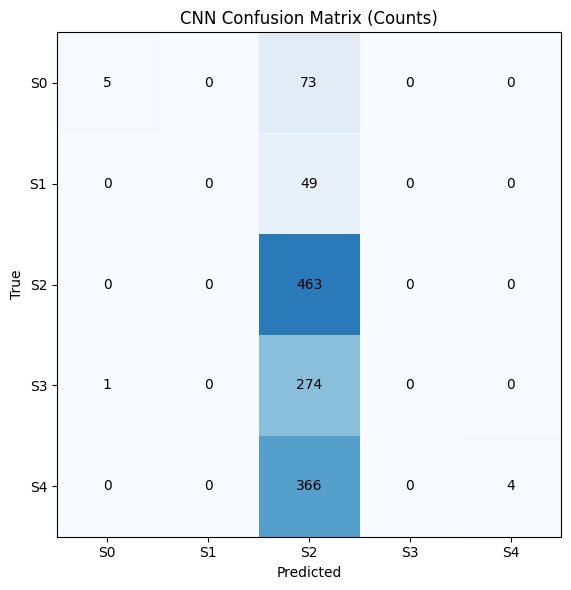

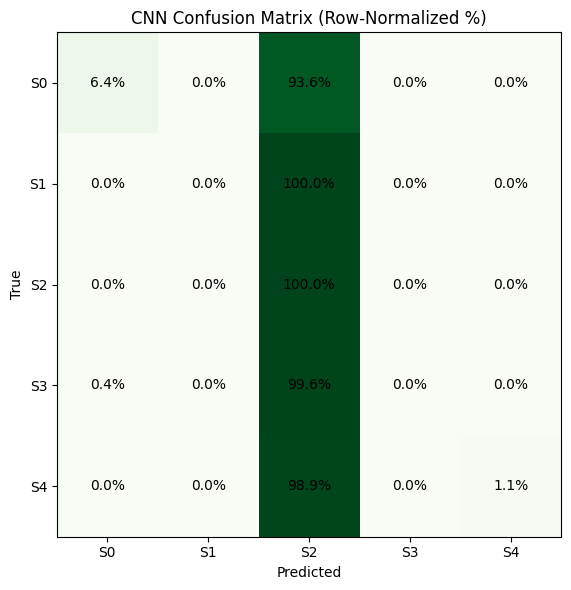

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Confusion matrix (rows=true, cols=pred) -----
labels = ["S0", "S1", "S2", "S3", "S4"]
cm = np.array([
    [  5,   0,  73,   0,   0],  # True S0
    [  0,   0,  49,   0,   0],  # True S1
    [  0,   0, 463,   0,   0],  # True S2
    [  1,   0, 274,   0,   0],  # True S3
    [  0,   0, 366,   0,   4],  # True S4
], dtype=int)

def annotate(ax, data, fmt):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, fmt(data[i, j]), ha="center", va="center", fontsize=10)

# ---------- Plot 1: raw counts (light Blues) ----------
plt.figure(figsize=(7, 6))
ax = plt.gca()
# use a light palette; bump vmax to keep tones pale
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max()*1.4)
ax.set_title("CNN Confusion Matrix (Counts)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
annotate(ax, cm, lambda x: f"{x:d}")
plt.tight_layout()
# plt.savefig("cnn_confusion_counts_light.png", dpi=150)
plt.show()

# ---------- Plot 2: row-normalized (%) (light Greens) ----------
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

plt.figure(figsize=(7, 6))
ax2 = plt.gca()
im2 = ax2.imshow(cm_norm, cmap="Greens", vmin=0.0, vmax=1.0)
ax2.set_title("CNN Confusion Matrix (Row-Normalized %)")
ax2.set_xlabel("Predicted")
ax2.set_ylabel("True")
ax2.set_xticks(np.arange(len(labels)))
ax2.set_yticks(np.arange(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_yticklabels(labels)
annotate(ax2, cm_norm, lambda x: f"{x*100:.1f}%")
plt.tight_layout()
# plt.savefig("cnn_confusion_normalized_light.png", dpi=150)
plt.show()

In [ ]:
#======Task 4: Advanced Modeling & Transfer Learning======

In [ ]:
# ============================
# TRANSFER LEARNING PIPELINE (COLAB, ONE CELL)
# MobileNetV2 on log-Mel spectrograms
# ============================

import os, random, numpy as np, pandas as pd, tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score, cohen_kappa_score, confusion_matrix
from scipy.signal import resample_poly
from tensorflow.keras import layers, models

# ---- set this path to your Drive folder ----
!cp -r /content/drive/MyDrive/dreem-automated-sleep-staging ./dreem


# Reproducibility
SEED = 1337
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# Data/layout
TRAIN_RECORDS = list(range(0,7))   # 0..6 are labeled
NUM_CLASSES   = 5
SR            = 128        # resample EEG to 128 Hz
EPOCH_SEC     = 30
SAMPLES_PER_EPOCH = SR * EPOCH_SEC   # 3840
EEG_OFFSETS   = [(1,7501),(7501,15001),(15001,22501),(22501,30001),(30001,37501)]  # 5 EEG montages
RGB_CHANS     = (0,1,2)    # which EEG channels → RGB

# Spectrogram/image
N_FFT   = 256
HOP     = 64
N_MELS  = 64
IMG_SIZE = 224             # 160/192/224 (MobileNetV2 supports these)

# Training
VAL_SPLIT, TEST_SPLIT = 0.16, 0.20
BS = 32
LR_S1, LR_S2 = 1e-3, 2e-4
EPOCHS_S1, EPOCHS_S2 = 20, 20
UNFREEZE_TOP = 30          # how many layers to unfreeze in stage-2

# ---- 1) Load labeled epochs (records 0..6), resample EEG 250Hz->128Hz ----
def load_dreem_epochs(data_root):
    df = pd.read_csv(os.path.join(data_root, "targets_train.csv"))
    df = df[df["record"].isin(TRAIN_RECORDS)].copy()

    cache = {}
    X_list, y_list = [], []
    for rid in sorted(TRAIN_RECORDS):
        if rid not in cache:
            cache[rid] = np.load(os.path.join(data_root, "training_records", f"record_{rid}.npy"))
        arr = cache[rid]
        sub = df[df["record"] == rid]
        for _, r in sub.iterrows():
            row = arr[int(r["index"])]  # [42001]
            # slice 5 EEG channels @250 Hz
            eeg_250 = np.stack([row[a:b] for (a,b) in EEG_OFFSETS], axis=-1).astype(np.float32)  # [7500,5]
            # resample to 128 Hz → 3840 samples
            eeg_128 = resample_poly(eeg_250, up=128, down=250, axis=0).astype(np.float32)        # [3840,5]
            X_list.append(eeg_128)
            y_list.append(int(r["target"]))
    X = np.stack(X_list)  # [N,3840,5]
    y = np.array(y_list, dtype=np.int64)
    return X, y

X_raw, y = load_dreem_epochs(DATA_ROOT)
print("EEG epochs:", X_raw.shape, "Labels:", y.shape)

# ---- 2) Build log-Mel spectrogram stacks (NO per-image min-max!) ----
def logmel_stack(epoch_2d):
    # epoch_2d: [3840,5] → [mel,frames,3]
    chans = []
    for ch in RGB_CHANS:
        x = tf.convert_to_tensor(epoch_2d[:, ch], dtype=tf.float32)
        stft = tf.signal.stft(x, frame_length=N_FFT, frame_step=HOP, fft_length=N_FFT, pad_end=True)
        power = tf.abs(stft)**2
        mel_w = tf.signal.linear_to_mel_weight_matrix(
            num_mel_bins=N_MELS, num_spectrogram_bins=stft.shape[-1], sample_rate=SR,
            lower_edge_hertz=0.5, upper_edge_hertz=30.0
        )
        mel = tf.tensordot(power, mel_w, axes=1)
        mel.set_shape(power.shape[:-1].concatenate(mel_w.shape[-1:]))
        logmel = tf.math.log(mel + 1e-6)     # [frames,mels]
        chans.append(tf.transpose(logmel))   # [mels,frames]
    img = tf.stack(chans, axis=-1)          # [mels,frames,3]
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method='bilinear')
    return img.numpy().astype('float32')

def build_image_array(X_raw):
    return np.stack([logmel_stack(x) for x in X_raw])

X_img_raw = build_image_array(X_raw)   # (N, IMG, IMG, 3) raw log-mel values
print("Raw log-mel range:", float(X_img_raw.min()), float(X_img_raw.max()))

# ---- 3) Split + TRAIN-set standardization → map to [0,255] for MobileNet ----
X_tr_raw, X_tmp_raw, y_tr, y_tmp = train_test_split(
    X_img_raw, y, test_size=(VAL_SPLIT+TEST_SPLIT), stratify=y, random_state=SEED
)
rel = TEST_SPLIT/(VAL_SPLIT+TEST_SPLIT)
X_va_raw, X_te_raw, y_va, y_te = train_test_split(
    X_tmp_raw, y_tmp, test_size=rel, stratify=y_tmp, random_state=SEED
)

# compute TRAIN stats per-channel (scalar per channel)
mu  = X_tr_raw.mean(axis=(0,1,2), keepdims=True)
std = X_tr_raw.std(axis=(0,1,2), keepdims=True) + 1e-6

def to_uint8_for_imagenet(x):
    z = (x - mu)/std             # z-score with TRAIN stats
    z = np.clip(z, -3.0, 3.0)    # robust clip
    # scale WHOLE DATASET to [0,1] via global min/max (use train stats for stability)
    # For simplicity in one cell, compute from z on-the-fly:
    z_min, z_max = z.min(), z.max()
    z = (z - z_min) / (z_max - z_min + 1e-8)
    return (z * 255.0).astype('float32')

X_tr = to_uint8_for_imagenet(X_tr_raw)
X_va = to_uint8_for_imagenet(X_va_raw)
X_te = to_uint8_for_imagenet(X_te_raw)

print("Final image dtype/range:", X_tr.dtype, float(X_tr.min()), float(X_tr.max()))
print("Splits:", X_tr.shape, X_va.shape, X_te.shape)

# class weights
cw_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_tr)
class_weight = {i: float(w) for i,w in enumerate(cw_arr)}
print("Class weights:", class_weight)

# one-hot for label smoothing
y_tr_oh = tf.keras.utils.to_categorical(y_tr, NUM_CLASSES)
y_va_oh = tf.keras.utils.to_categorical(y_va, NUM_CLASSES)
y_te_oh = tf.keras.utils.to_categorical(y_te, NUM_CLASSES)

# ---- 4) Model: MobileNetV2 head (frozen → finetune) ----
def build_tl_mobilenet(input_shape=(IMG_SIZE,IMG_SIZE,3), base_trainable=False):
    base = tf.keras.applications.MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = base_trainable
    inp = layers.Input(shape=input_shape)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inp)   # expects [0,255]
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = models.Model(inp, out)
    return model, base

def compile_model(model, lr):
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
                  metrics=['accuracy'])

def train_and_report(model, Xtr, ytr, Xva, yva, Xte, yte, name):
    cb = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=4, factor=0.5, min_lr=1e-6),
    ]
    model.fit(Xtr, ytr, validation_data=(Xva, yva),
              epochs=20, batch_size=BS, class_weight=class_weight, callbacks=cb, verbose=1)

    y_prob = model.predict(Xte, verbose=0)
    y_pred = y_prob.argmax(1); y_true = yte.argmax(1)

    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    kappa    = cohen_kappa_score(y_true, y_pred)
    print(f"\n{name}  Macro-F1={macro_f1:.4f}  Kappa={kappa:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=3))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    return macro_f1, kappa

# Stage-1: frozen base
model, base = build_tl_mobilenet(base_trainable=False)
compile_model(model, LR_S1)
s1 = train_and_report(model, X_tr, y_tr_oh, X_va, y_va_oh, X_te, y_te_oh, "Stage-1 Frozen")

# Stage-2: unfreeze top-K conv layers (keep BatchNorm frozen)
for layer in base.layers[-UNFREEZE_TOP:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True
    else:
        layer.trainable = False
compile_model(model, LR_S2)
s2 = train_and_report(model, X_tr, y_tr_oh, X_va, y_va_oh, X_te, y_te_oh, "Stage-2 Fine-tune")

print("\nSUMMARY (Macro-F1, Kappa):")
print("Stage-1:", s1)
print("Stage-2:", s2)


EEG epochs: (6175, 3840, 5) Labels: (6175,)
Raw log-mel range: -9.430434226989746 37.42789077758789
Final image dtype/range: float32 0.0 255.0
Splits: (3952, 224, 224, 3) (988, 224, 224, 3) (1235, 224, 224, 3)
Class weights: {0: 3.17429718875502, 1: 5.066666666666666, 2: 0.5329737019554956, 3: 0.8981818181818182, 4: 0.6675675675675675}
Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 40s 225ms/step - accuracy: 0.2800 - loss: 1.8617 - val_accuracy: 0.5243 - val_loss: 1.3901 - learning_rate: 0.0010
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3926 - loss: 1.3581 - val_accuracy: 0.3340 - val_loss: 1.4136 - learning_rate: 0.0010
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4530 - loss: 1.2690 - val_accuracy: 0.3664 - val_loss: 1.3874 - learning_rate: 0.0010
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4601 - loss: 1.2383 - val_accuracy: 0.4696 - val_loss: 1.3538 - learning_rate: 0.0010
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/

In [ ]:
# ============================
# CNN → BiLSTM transfer learning (frozen → fine-tune)
# Uses MobileNetV2 as a pretrained feature extractor on each time-slice of the spectrogram,
# then a BiLSTM head to model temporal dependencies across slices.
# ============================

from tensorflow.keras import layers, models
import tensorflow as tf

def build_tl_cnn_bilstm(input_shape=(IMG_SIZE, IMG_SIZE, 3), time_slices=14, base_trainable=False):
    """
    Returns:
      model: full CNN→BiLSTM classifier
      base:  the MobileNetV2 backbone you can unfreeze for fine-tuning
    """
    # Pretrained CNN backbone
    base = tf.keras.applications.MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = base_trainable

    # Feature extractor block with proper preprocessing
    feat_extractor = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Lambda(lambda z: tf.keras.applications.mobilenet_v2.preprocess_input(z)),  # expects [0,255]
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
    ], name="cnn_feature_extractor")

    # Slice the spectrogram along WIDTH (time) into T segments, then extract features per slice
    def slice_time(x):
        # x: [B, H, W, C]  ->  stack([B, H, w, C] * T) -> [B, T, H, W, C] after resize
        W = tf.shape(x)[2]
        w = IMG_SIZE // time_slices  # assume IMG_SIZE is divisible by time_slices (e.g., 224//14=16)
        crops = []
        for s in range(time_slices):
            start = s * w
            end   = start + w
            crop = x[:, :, start:end, :]                 # [B, H, w, C]
            crop = tf.image.resize(crop, (IMG_SIZE, IMG_SIZE))
            crops.append(crop)
        return tf.stack(crops, axis=1)                   # [B, T, H, W, C]

    inp = layers.Input(shape=input_shape)
    seq_imgs = layers.Lambda(slice_time, name="time_slicer")(inp)      # [B,T,H,W,C]
    td_feats = layers.TimeDistributed(feat_extractor, name="TD_Feats")(seq_imgs)  # [B,T,D]

    # BiLSTM head across time slices
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(td_feats)
    x = layers.Bidirectional(layers.LSTM(64))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inp, out, name="TL_CNN_BiLSTM")
    return model, base

# ----- Stage 1: Frozen CNN features -> BiLSTM head -----
model_bilstm, base_bilstm = build_tl_cnn_bilstm(base_trainable=False, time_slices=14)
compile_model(model_bilstm, lr=LR_S1)  # uses label smoothing from earlier cell
print(model_bilstm.summary())
s1_bilstm = train_and_report(model_bilstm, X_tr, y_tr_oh, X_va, y_va_oh, X_te, y_te_oh,
                             name="CNN→BiLSTM  | Stage-1 (Frozen)")

# ----- Stage 2: Unfreeze top-K CNN layers (keep BatchNorm frozen) & fine-tune -----
for layer in base_bilstm.layers[-UNFREEZE_TOP:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True
    else:
        layer.trainable = False

compile_model(model_bilstm, lr=LR_S2)
s2_bilstm = train_and_report(model_bilstm, X_tr, y_tr_oh, X_va, y_va_oh, X_te, y_te_oh,
                             name=f"CNN→BiLSTM  | Stage-2 (Fine-tune top {UNFREEZE_TOP})")

print("\nSUMMARY (CNN→BiLSTM)  Stage-1 vs Stage-2:")
print("Stage-1:", s1_bilstm)
print("Stage-2:", s2_bilstm)


Model: "TL_CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_33 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_slicer (Lambda)            │ (None, 14, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TD_Feats (TimeDistributed)      │ (None, 14, 1280)       │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 14, 256)        │     1,442,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,865,797 (14.75 MB)

 Trainable params: 1,607,813 (6.13 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None
Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 141s 721ms/step - accuracy: 0.2213 - loss: 1.6445 - val_accuracy: 0.4140 - val_loss: 1.3832 - learning_rate: 0.0010
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 72s 579ms/step - accuracy: 0.3900 - loss: 1.3762 - val_accuracy: 0.2905 - val_loss: 1.4408 - learning_rate: 0.0010
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 72s 579ms/step - accuracy: 0.4168 - loss: 1.3077 - val_accuracy: 0.4099 - val_loss: 1.4021 - learning_rate: 0.0010
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 72s 579ms/step - accuracy: 0.4950 - loss: 1.1859 - val_accuracy: 0.4737 - val_loss: 1.3392 - learning_rate: 0.0010
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 72s 579ms/step - accuracy: 0.5283 - loss: 1.1381 - val_accuracy: 0.4504 - val_loss: 1.3894 - learning_rate: 0.0010
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 72s 579ms/step - accuracy: 0.5540 - loss: 1.1177 - val_accuracy: 0.3411 - val_loss: 1.6376 - learning_rate: 0.0010
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 72s 579ms/step - accurac

TF: 2.19.0  | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Loaded: (6175, 3840, 5) labels: [ 389  244 2317 1375 1850]
[LOEO] event 0: acc=0.300 f1=0.159
[LOEO] event 1: acc=0.293 f1=0.125


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[LOEO] event 2: acc=0.311 f1=0.122
[LOEO] event 3: acc=0.347 f1=0.145


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[LOEO] event 4: acc=0.462 f1=0.150


...

[LOSO] subject 4: acc=0.343 f1=0.114


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[LOSO] subject 5: acc=0.413 f1=0.257


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[LOSO] subject 6: acc=0.274 f1=0.099

LOSO mean ± std:
           mean    std
acc      0.331  0.050
f1       0.144  0.054
prec     0.333  0.128
rec      0.220  0.034
kappa    0.024  0.056
subject  3.000  2.160


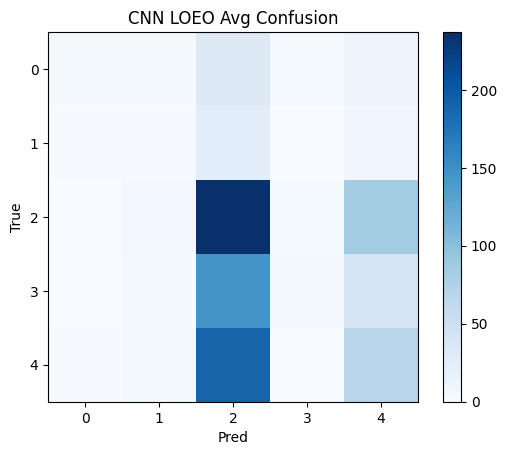

[Window 1s] acc=0.508, f1=0.436
[Window 2s] acc=0.533, f1=0.440
[Window 3s] acc=0.528, f1=0.409
[Window 5s] acc=0.546, f1=0.425
[Window 6s] acc=0.338, f1=0.286
[Window 10s] acc=0.333, f1=0.307
[Window 12s] acc=0.422, f1=0.275
[Window 15s] acc=0.388, f1=0.285
[Window 20s] acc=0.418, f1=0.264
[Window 30s] acc=0.422, f1=0.272

Window-size results:
    window_s    acc     f1
0         1  0.508  0.436
1         2  0.533  0.440
2         3  0.528  0.409
3         5  0.546  0.425
4         6  0.338  0.286
5        10  0.333  0.307
6        12  0.422  0.275
7        15  0.388  0.285
8        20  0.418  0.264
9        30  0.422  0.272


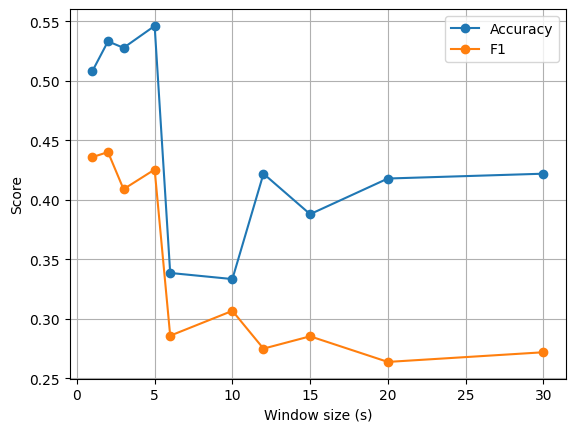


Comparison LOEO vs LOSO (CNN):


,metric,LOEO_mean,LOSO_mean
0,Accuracy,0.356,0.331
1,Macro-F1,0.150,0.144
2,Kappa,0.026,0.024


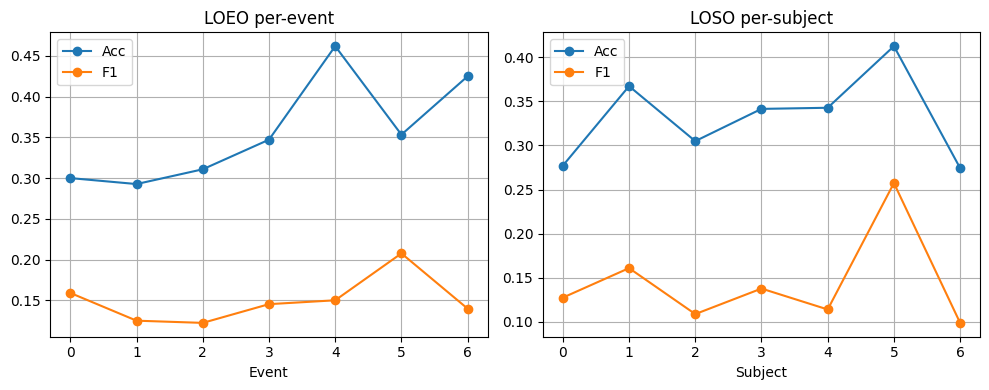

In [ ]:
# =========================
# CNN Evaluation & Comparative Analysis
# =========================
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             accuracy_score, cohen_kappa_score)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# -------------------- Setup --------------------
np.random.seed(42); tf.random.set_seed(42)
for g in tf.config.list_physical_devices('GPU'):
    try: tf.config.experimental.set_memory_growth(g, True)
    except: pass
print("TF:", tf.__version__, " | GPUs:", tf.config.list_physical_devices('GPU'))

BASE_PATH    = "/content/drive/MyDrive/dreem-automated-sleep-staging"
RECORDS_PATH = os.path.join(BASE_PATH, "training_records")
TARGETS_PATH = os.path.join(BASE_PATH, "targets_train.csv")
assert os.path.exists(RECORDS_PATH) and os.path.exists(TARGETS_PATH)

# -------------------- Preprocessing --------------------
def bandpass_filter(signal, fs, lowcut=0.5, highcut=45, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

def load_raw_signals_with_events():
    targets = pd.read_csv(TARGETS_PATH)
    channel_specs = {
        'eeg1': (1,     7501, 250, 0.5, 45),
        'eeg2': (7501, 15001, 250, 0.5, 45),
        'eeg3': (15001,22501, 250, 0.5, 45),
        'eeg4': (22501,30001, 250, 0.5, 45),
        'eeg5': (30001,37501, 250, 0.5, 45),
    }
    TARGET_FS = 128
    X, y, events = [], [], []
    record_ids = sorted([int(f.split('_')[-1].split('.')[0])
                         for f in os.listdir(RECORDS_PATH) if f.startswith("record_")])
    for rid in record_ids:
        path = os.path.join(RECORDS_PATH, f"record_{rid}.npy")
        if not os.path.exists(path): continue
        data = np.load(path, allow_pickle=True)
        rec_t = targets[targets['record']==rid].set_index('index')
        for row in data:
            idx = int(row[0])
            if idx not in rec_t.index: continue
            label = int(rec_t.loc[idx]['target'])
            chans=[]
            for ch in ['eeg1','eeg2','eeg3','eeg4','eeg5']:
                s,e,fs0,lo,hi=channel_specs[ch]
                raw=row[s:e]
                L=int(len(raw)*TARGET_FS/fs0)
                x=resample(raw,L)
                x=bandpass_filter(x,TARGET_FS,lo,hi)
                chans.append(x)
            X.append(np.stack(chans,axis=1))
            y.append(label); events.append(rid)
    return np.array(X,dtype='float32'), np.array(y,int), np.array(events,int)

X_all, y_all, event_ids = load_raw_signals_with_events()
num_classes = 5
print("Loaded:", X_all.shape, "labels:", np.bincount(y_all))

# -------------------- Normalization --------------------
def zscore_fit(X):
    mu = X.mean(axis=(0,1))
    sd = X.std(axis=(0,1)); sd[sd<1e-8]=1e-8
    return mu, sd
def zscore_apply(X, mu, sd): return (X - mu) / sd

# -------------------- Class weights --------------------
def class_weight_dict(y, K=5):
    c=np.bincount(y,minlength=K).astype(float); t=c.sum()
    return {i:float(t/(K*max(ci,1))) for i,ci in enumerate(c)}

# -------------------- CNN builder --------------------
def build_cnn_raw(input_shape):
    m=models.Sequential(name="CNN_Raw")
    m.add(layers.Input(shape=input_shape))
    m.add(layers.Conv1D(32,15,padding='same',activation=None))
    m.add(layers.BatchNormalization()); m.add(layers.Activation('relu'))
    m.add(layers.MaxPooling1D(4)); m.add(layers.Dropout(0.3))
    m.add(layers.Conv1D(64,11,padding='same',activation=None))
    m.add(layers.BatchNormalization()); m.add(layers.Activation('relu'))
    m.add(layers.MaxPooling1D(4)); m.add(layers.Dropout(0.3))
    m.add(layers.Conv1D(128,7,padding='same',activation=None))
    m.add(layers.BatchNormalization()); m.add(layers.Activation('relu'))
    m.add(layers.MaxPooling1D(4)); m.add(layers.Dropout(0.3))
    m.add(layers.GlobalAveragePooling1D())
    m.add(layers.Dense(128,activation='relu'))
    m.add(layers.BatchNormalization()); m.add(layers.Dropout(0.3))
    m.add(layers.Dense(num_classes,activation='softmax'))
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
    return m

# -------------------- Training helper --------------------
def train_one_fold(Xtr,ytr,Xva,yva,Xte,yte,epochs=15,batch=64):
    cw=class_weight_dict(ytr)
    model=build_cnn_raw(Xtr.shape[1:])
    es=EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True,verbose=0)
    rl=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=4,min_lr=1e-6,verbose=0)
    model.fit(Xtr,ytr,validation_data=(Xva,yva),epochs=epochs,batch_size=batch,
              class_weight=cw,callbacks=[es,rl],verbose=0)
    y_pred=np.argmax(model.predict(Xte,verbose=0),axis=1)
    return dict(
        acc=accuracy_score(yte,y_pred),
        f1=f1_score(yte,y_pred,average='macro'),
        prec=precision_score(yte,y_pred,average='macro'),
        rec=recall_score(yte,y_pred,average='macro'),
        kappa=cohen_kappa_score(yte,y_pred)
    ), confusion_matrix(yte,y_pred)

# =========================================================
# 1. LOEO — Leave-One-Event-Out
# =========================================================
uniq=np.unique(event_ids)
loeo=[]
cms_loeo={}
for e in uniq:
    te=(event_ids==e); tr=~te
    Xtr,ytr=X_all[tr],y_all[tr]; Xte,yte=X_all[te],y_all[te]
    mu,sd=zscore_fit(Xtr)
    Xtr,Xte=zscore_apply(Xtr,mu,sd),zscore_apply(Xte,mu,sd)
    Xtr,Xva,ytr,yva=train_test_split(Xtr,ytr,test_size=0.15,random_state=42,stratify=ytr)
    m,cm=train_one_fold(Xtr,ytr,Xva,yva,Xte,yte,epochs=15)
    m['event']=int(e); loeo.append(m); cms_loeo[int(e)]=cm
    print(f"[LOEO] event {e}: acc={m['acc']:.3f} f1={m['f1']:.3f}")
loeo_df=pd.DataFrame(loeo)
print("\nLOEO mean ± std:\n", loeo_df.describe().T[['mean','std']].round(3))

# =========================================================
# 2. LOSO — Leave-One-Subject-Out (if subject==record)
# =========================================================
subjects=event_ids.copy()  # 1:1 mapping
loso=[]; cms_loso={}
for s in np.unique(subjects):
    te=(subjects==s); tr=~te
    Xtr,ytr=X_all[tr],y_all[tr]; Xte,yte=X_all[te],y_all[te]
    mu,sd=zscore_fit(Xtr)
    Xtr,Xte=zscore_apply(Xtr,mu,sd),zscore_apply(Xte,mu,sd)
    Xtr,Xva,ytr,yva=train_test_split(Xtr,ytr,test_size=0.15,random_state=42,stratify=ytr)
    m,cm=train_one_fold(Xtr,ytr,Xva,yva,Xte,yte,epochs=15)
    m['subject']=int(s); loso.append(m); cms_loso[int(s)]=cm
    print(f"[LOSO] subject {s}: acc={m['acc']:.3f} f1={m['f1']:.3f}")
loso_df=pd.DataFrame(loso)
print("\nLOSO mean ± std:\n", loso_df.describe().T[['mean','std']].round(3))

# =========================================================
# 3. Confusion matrix (average)
# =========================================================
def avg_cm(cms):
    mats=list(cms.values())
    return np.round(sum(mats)/len(mats)).astype(int)
avg_loeo_cm=avg_cm(cms_loeo)
plt.imshow(avg_loeo_cm,cmap='Blues'); plt.title("CNN LOEO Avg Confusion"); plt.xlabel("Pred"); plt.ylabel("True")
plt.colorbar(); plt.show()

# =========================================================
# 4. Window-size comparison (10 sizes)
# =========================================================
FS=128
WINDOW_S=[1,2,3,5,6,10,12,15,20,30]
def epoch_to_windows(X_epoch,win_s,fs=128):
    T,C=X_epoch.shape; L=int(win_s*fs); n=T//L
    return np.reshape(X_epoch[:n*L],(n,L,C)) if n>0 else np.empty((0,L,C))
def build_tiny_cnn(input_shape):
    m=models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(32,7,padding='same',activation='relu'),
        layers.MaxPooling1D(2),
        layers.Conv1D(64,5,padding='same',activation='relu'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64,activation='relu'),
        layers.Dense(num_classes,activation='softmax')
    ])
    m.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return m
win_rows=[]
for w in WINDOW_S:
    Xw_list,yw_list=[],[]
    for i in range(len(X_all)):
        Ws=epoch_to_windows(X_all[i],w,fs=FS)
        if Ws.size==0: continue
        Xw_list.append(Ws); yw_list.append(np.full(Ws.shape[0],y_all[i],int))
    if not Xw_list: continue
    Xw=np.concatenate(Xw_list,axis=0); yw=np.concatenate(yw_list,axis=0)
    Xtrv,Xte,ytrv,yte=train_test_split(Xw,yw,test_size=0.2,random_state=42,stratify=yw)
    mu,sd=zscore_fit(Xtrv); Xtrv=zscore_apply(Xtrv,mu,sd); Xte=zscore_apply(Xte,mu,sd)
    Xtr,Xva,ytr,yva=train_test_split(Xtrv,ytrv,test_size=0.2,random_state=42,stratify=ytrv)
    cw=class_weight_dict(ytr)
    m=build_tiny_cnn(Xtr.shape[1:])
    es=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True,verbose=0)
    m.fit(Xtr,ytr,validation_data=(Xva,yva),epochs=10,batch_size=64,class_weight=cw,callbacks=[es],verbose=0)
    y_pred=np.argmax(m.predict(Xte,verbose=0),axis=1)
    win_rows.append(dict(window_s=w,
                         acc=accuracy_score(yte,y_pred),
                         f1=f1_score(yte,y_pred,average='macro')))
    print(f"[Window {w}s] acc={win_rows[-1]['acc']:.3f}, f1={win_rows[-1]['f1']:.3f}")
win_df=pd.DataFrame(win_rows)
print("\nWindow-size results:\n",win_df.round(3))
plt.plot(win_df['window_s'],win_df['acc'],'-o',label='Accuracy')
plt.plot(win_df['window_s'],win_df['f1'],'-o',label='F1')
plt.xlabel("Window size (s)"); plt.ylabel("Score"); plt.legend(); plt.grid(); plt.show()

# =========================================================
# 5. Comparison table: LOEO vs LOSO (CNN only)
# =========================================================
compare_df=pd.DataFrame({
    "metric":["Accuracy","Macro-F1","Kappa"],
    "LOEO_mean":[loeo_df['acc'].mean(),loeo_df['f1'].mean(),loeo_df['kappa'].mean()],
    "LOSO_mean":[loso_df['acc'].mean(),loso_df['f1'].mean(),loso_df['kappa'].mean()]
}).round(3)
print("\nComparison LOEO vs LOSO (CNN):")
display(compare_df)

# =========================================================
# 6. Performance plots
# =========================================================
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].plot(loeo_df['event'],loeo_df['acc'],'-o',label='Acc'); ax[0].plot(loeo_df['event'],loeo_df['f1'],'-o',label='F1')
ax[0].set_title("LOEO per-event"); ax[0].set_xlabel("Event"); ax[0].legend(); ax[0].grid()
ax[1].plot(loso_df['subject'],loso_df['acc'],'-o',label='Acc'); ax[1].plot(loso_df['subject'],loso_df['f1'],'-o',label='F1')
ax[1].set_title("LOSO per-subject"); ax[1].set_xlabel("Subject"); ax[1].legend(); ax[1].grid()
plt.tight_layout(); plt.show()

                                 Accuracy  Precision  Recall     F1  Kappa
Model                                                                     
XGBoost                             0.820      0.711   0.660  0.674    NaN
Pretrained CNN (Stage-2 Frozen)     0.712      0.531   0.597  0.623  0.463
Random Forest                       0.809      0.625   0.602  0.610    NaN
AdaBoost                            0.732      0.621   0.551  0.573    NaN
Decision Tree                       0.738      0.578   0.560  0.567    NaN
RNN                                 0.381      0.288   0.239  0.183    NaN
Logistic Regression                 0.181      0.193   0.232  0.145    NaN
SVM                                 0.410      0.281   0.214  0.142    NaN
CNN                                 0.381      0.290   0.214  0.138    NaN
Naive Bayes                         0.202      0.224   0.218  0.104    NaN
CNN→BiLSTM (Stage-2 Frozen)         0.662      0.551   0.546  0.006  0.427


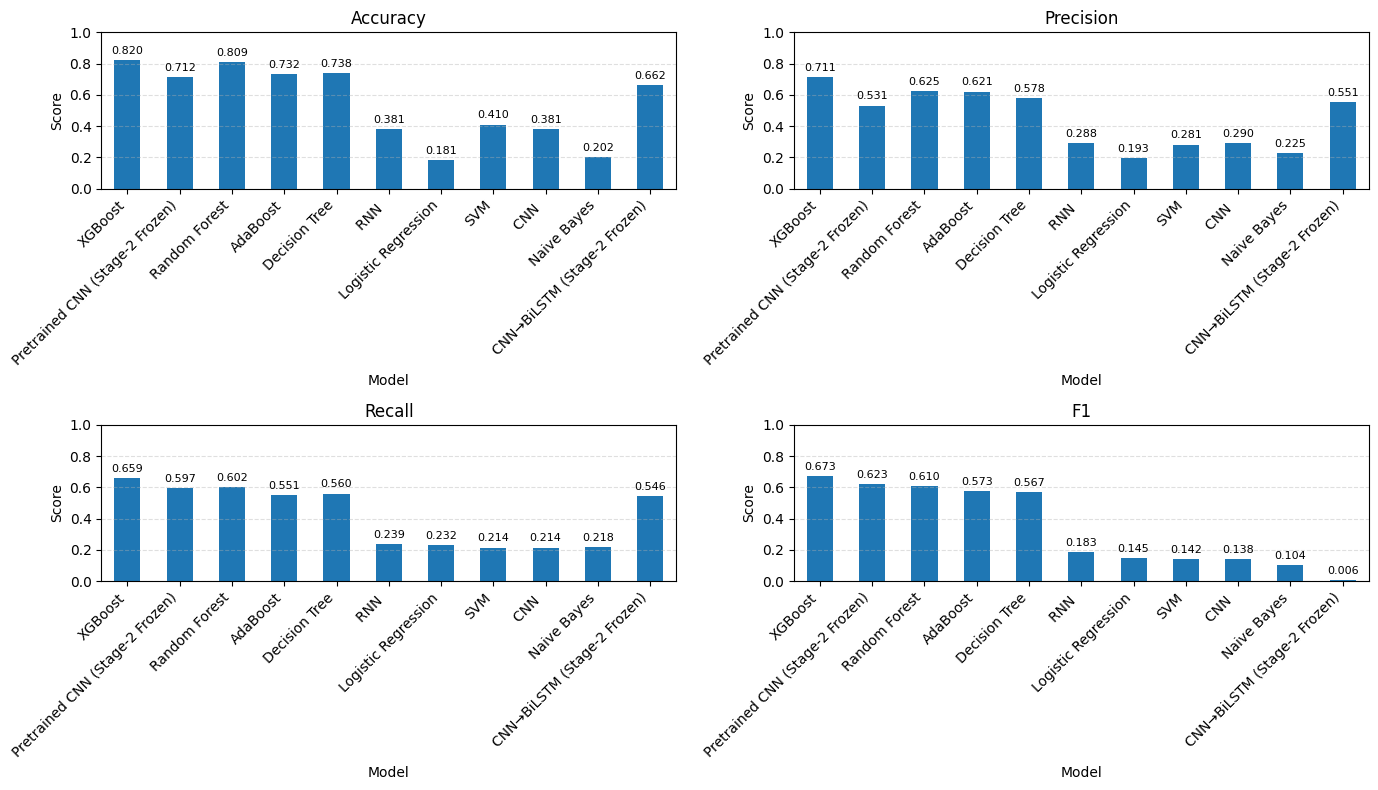

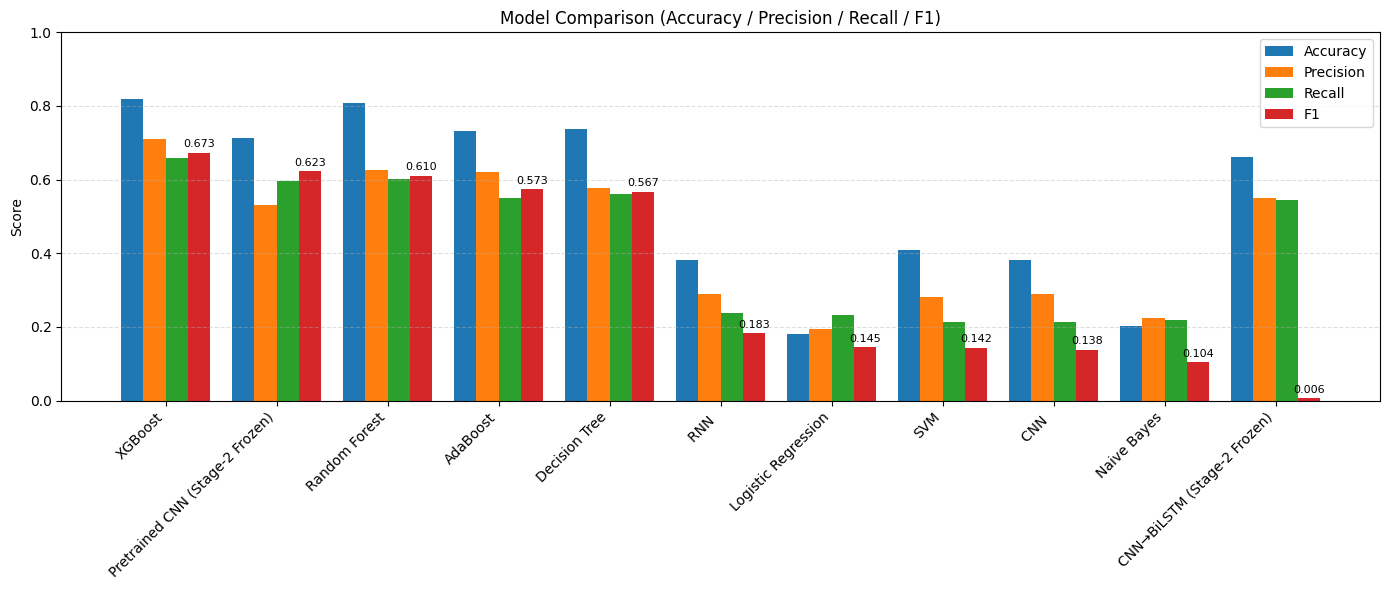

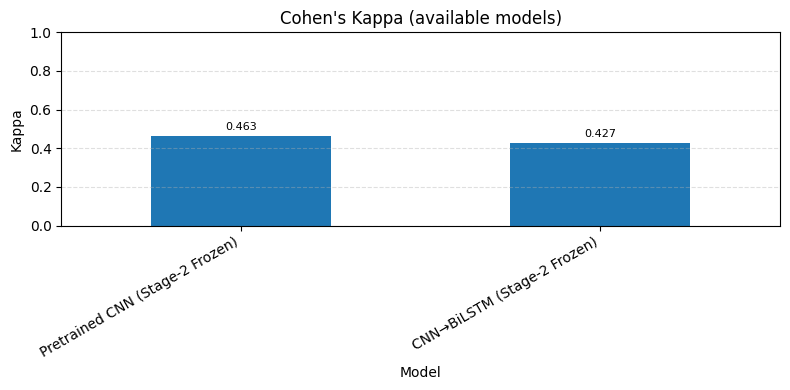

In [ ]:
# ===============================
# Compare ML & DL models (plots)
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Entered from your results ----
rows = [
    # Classic ML (80/20 split)
    {"Model": "Decision Tree",        "Accuracy": 0.7377, "Precision": 0.5779, "Recall": 0.5601, "F1": 0.5669},
    {"Model": "Random Forest",        "Accuracy": 0.8087, "Precision": 0.6253, "Recall": 0.6018, "F1": 0.6096},
    {"Model": "SVM",                  "Accuracy": 0.4098, "Precision": 0.2813, "Recall": 0.2143, "F1": 0.1423},
    {"Model": "Naive Bayes",          "Accuracy": 0.2022, "Precision": 0.2245, "Recall": 0.2182, "F1": 0.1040},
    {"Model": "Logistic Regression",  "Accuracy": 0.1808, "Precision": 0.1931, "Recall": 0.2319, "F1": 0.1447},
    {"Model": "AdaBoost",             "Accuracy": 0.7322, "Precision": 0.6209, "Recall": 0.5507, "F1": 0.5734},
    {"Model": "XGBoost",              "Accuracy": 0.8197, "Precision": 0.7111, "Recall": 0.6595, "F1": 0.6735},

    # Deep learning (test results you posted)
    {"Model": "CNN ",            "Accuracy": 0.3806, "Precision": 0.2899, "Recall": 0.2141, "F1": 0.1381},
    {"Model": "RNN ",            "Accuracy": 0.3814, "Precision": 0.2885, "Recall": 0.2386, "F1": 0.1829},

    # Transfer / staged models (macro metrics from your reports)
    {"Model": "CNN→BiLSTM (Stage-2 Frozen)", "Accuracy": 0.662, "Precision": 0.5510, "Recall": 0.5460, "F1": 0.005802, "Kappa": 0.4274},
    {"Model": "Pretrained CNN (Stage-2 Frozen)", "Accuracy": 0.7120, "Precision": 0.5310, "Recall": 0.5970, "F1": 0.6227, "Kappa": 0.4631},
]

df = pd.DataFrame(rows)

# If you prefer macro metrics everywhere, the ML numbers you gave already look macro-like.
# For models without Kappa, leave NaN.
df = df.set_index("Model")

# ---- Sort models by F1 (best at top)
df_sorted = df.sort_values("F1", ascending=False)
print(df_sorted.round(3))

# ---- Helper to annotate bars
def annotate_bars(ax, fmt="{:.3f}"):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(fmt.format(height),
                    (p.get_x() + p.get_width() / 2, height),
                    ha="center", va="bottom", fontsize=8, rotation=0, xytext=(0, 3),
                    textcoords="offset points")

# ---- Plot individual metric bar charts
metrics = ["Accuracy", "Precision", "Recall", "F1"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for i, metric in enumerate(metrics):
    ax = axes[i]
    y = df_sorted[metric]
    y.plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Score")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    annotate_bars(ax)
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
        tick.set_ha("right")

plt.tight_layout()
plt.savefig("model_comparison_accuracy_precision_recall_f1.png", dpi=200)
plt.show()

# ---- Optional: combined grouped bar chart for the 4 metrics
fig, ax = plt.subplots(figsize=(14, 6))
idx = np.arange(len(df_sorted))
width = 0.2

ax.bar(idx - 1.5*width, df_sorted["Accuracy"], width, label="Accuracy")
ax.bar(idx - 0.5*width, df_sorted["Precision"], width, label="Precision")
ax.bar(idx + 0.5*width, df_sorted["Recall"],    width, label="Recall")
ax.bar(idx + 1.5*width, df_sorted["F1"],        width, label="F1")

ax.set_xticks(idx)
ax.set_xticklabels(df_sorted.index, rotation=45, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Model Comparison (Accuracy / Precision / Recall / F1)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Add value labels for F1 only (least clutter); comment out if you want all
for i, v in enumerate(df_sorted["F1"].values):
    ax.text(i + 1.5*width, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison_grouped.png", dpi=200)
plt.show()

# ---- Optional: Kappa bar chart (only models that have it)
if "Kappa" in df_sorted.columns and df_sorted["Kappa"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 4))
    kappa_series = df_sorted["Kappa"].dropna()
    kappa_series.plot(kind="bar", ax=ax)
    ax.set_title("Cohen's Kappa (available models)")
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Kappa")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    annotate_bars(ax)
    for tick in ax.get_xticklabels():
        tick.set_rotation(30); tick.set_ha("right")
    plt.tight_layout()
    plt.savefig("model_comparison_kappa.png", dpi=200)
    plt.show()